# PROJECT PENELITIAN 2026

# 900

## IMPORT

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import requests
import io
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

## Pre Processing

In [ ]:
url = "https://raw.githubusercontent.com/hqq24/project/main/Latent%20Variabel%20(data%20untuk%20ML)%20penelitian%202026.csv"
response = requests.get(url)
content = response.content.decode('utf-8')

# Gunakan StringIO untuk membaca file dan skip baris yang tidak perlu
df = pd.read_csv(io.StringIO(content), skiprows=5)

# Bersihkan nama kolom
df.columns = df.columns.str.strip()

# Hapus kolom yang tidak bernama
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Hapus baris kosong
df = df.dropna(how='all')

print(f"Jumlah baris data: {df.shape[0]}")
print("Kolom yang ditemukan:")
print(df.columns.tolist())
print("\nPreview Data:")
print(df.head())

Jumlah baris data: 900
Kolom yang ditemukan:
['Case ID', 'Attitude Toward Local Brand (ATLB)', 'Consumer Ethnocentrism (CET)', 'Gov. Buy Local Campaign Effectiveness  (PBLCE)', 'Local Fashion Brand Love (LFBL)', 'Perceived Price Fairness (PPF)', 'Perceived Product Quality (PPQ)']

Preview Data:
   Case ID  Attitude Toward Local Brand (ATLB)  Consumer Ethnocentrism (CET)  \
0        1                            0.127239                      0.869968   
1        2                            0.459847                      0.394250   
2        3                            0.404620                      0.978381   
3        4                            0.670074                     -1.142631   
4        5                            1.004079                      0.394250   

   Gov. Buy Local Campaign Effectiveness  (PBLCE)  \
0                                        0.398522   
1                                        0.412926   
2                                        0.427216   
3          

In [ ]:
# pembagian Model A
features_a = ['Perceived Product Quality (PPQ)',
              'Perceived Price Fairness (PPF)',
              'Gov. Buy Local Campaign Effectiveness  (PBLCE)',
              'Consumer Ethnocentrism (CET)']

# pembagian Model B
features_b = features_a + ['Attitude Toward Local Brand (ATLB)']

# variabel target
target = 'Local Fashion Brand Love (LFBL)'

## RANDOM FOREST

In [ ]:
def process_rf_model(features_list, target_col, df_source, model_name):
    X = df_source[features_list]
    y = df_source[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Parameter grid disederhanakan agar prosesnya kilat
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt', 'log2']
    }

    # Menggunakan n_jobs=-1 agar seluruh inti prosesor bekerja serentak
    rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
    grid = GridSearchCV(rf_base, param_grid, cv=5, scoring='r2', n_jobs=-1)

    print(f"\nSedang melatih {model_name}...")
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    results = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

    return results, best_model, X_test, y_test, y_pred

In [ ]:
try:
    res_a, model_a, X_test_a, y_test_a, y_pred_a = process_rf_model(features_a, target, df, "Model A (Tanpa ATLB)")
    res_b, model_b, X_test_b, y_test_b, y_pred_b = process_rf_model(features_b, target, df, "Model B (Dengan ATLB)")

    df_results = pd.DataFrame([res_a, res_b])

    print("\n--- Perbandingan Performa Akhir ---")
    print(df_results)
except Exception as e:
    print(f"\nTerjadi Kesalahan: {e}")


Sedang melatih Model A (Tanpa ATLB)...

Sedang melatih Model B (Dengan ATLB)...

--- Perbandingan Performa Akhir ---
                   Model      RMSE       MAE        R2
0   Model A (Tanpa ATLB)  0.720303  0.530454  0.449630
1  Model B (Dengan ATLB)  0.684525  0.490533  0.502947



Membuat Visualisasi Permutation Importance...


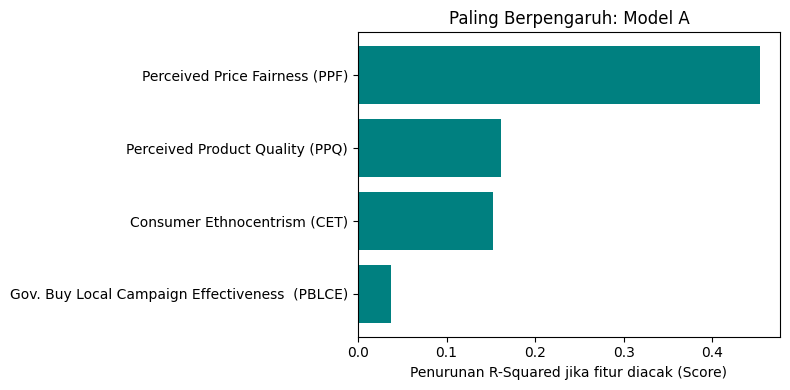

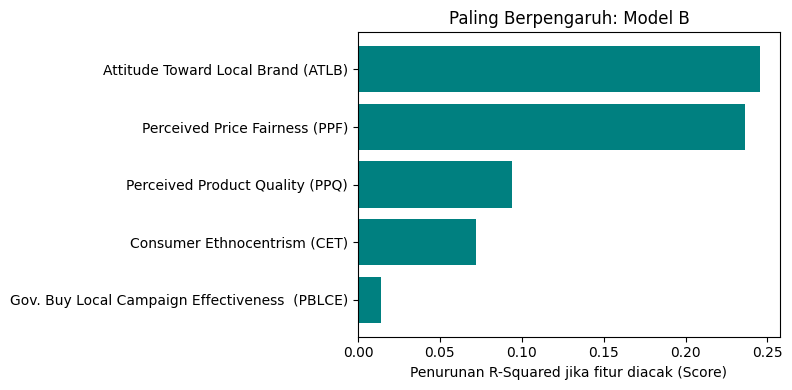

In [ ]:
def plot_importance(model, features, X_test, y_test, name):
    perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='r2')

    importance_df = pd.DataFrame({'Feature': features, 'Importance': perm_importance.importances_mean})
    importance_df = importance_df.sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(8, 4))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
    plt.title(f'Paling Berpengaruh: {name}')
    plt.xlabel('Penurunan R-Squared jika fitur diacak (Score)')
    plt.tight_layout()
    plt.show()

print("\nMembuat Visualisasi Permutation Importance...")
plot_importance(model_a, features_a, X_test_a, y_test_a, "Model A")
plot_importance(model_b, features_b, X_test_b, y_test_b, "Model B")


--- 10 Sampel Prediksi Model A (Tanpa Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
70  -0.929547  0.307709        -1.237256
827  1.573347  0.849721         0.723626
231 -0.111096  0.340113        -0.451208
588 -0.680170  0.118804        -0.798974
39  -0.070657  0.281612        -0.352269
731 -0.123198 -0.218196         0.094997
299  0.112650  0.506841        -0.394191
110 -1.867044  0.308828        -2.175872
72  -0.993911 -1.076679         0.082768
86   1.011655 -0.897527         1.909182


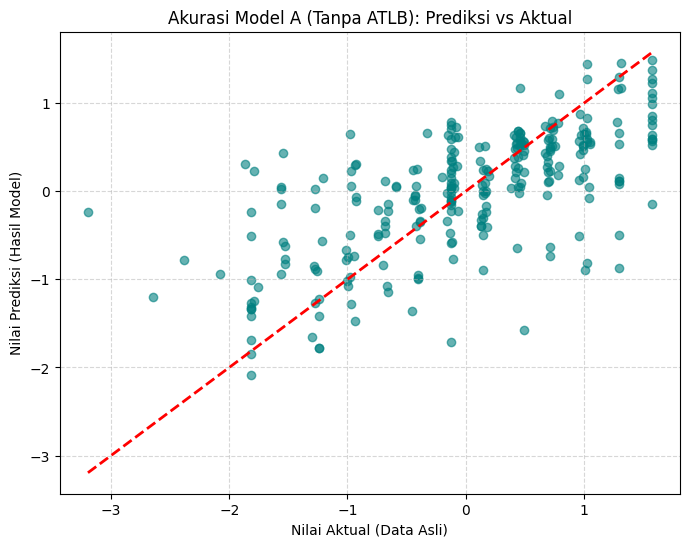

In [ ]:
hasil_prediksi_a = pd.DataFrame({
    'Aktual': y_test_a,
    'Prediksi': y_pred_a,
    'Selisih (Error)': y_test_a - y_pred_a
})

print("\n--- 10 Sampel Prediksi Model A (Tanpa Mediator ATLB) ---")
print(hasil_prediksi_a.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_a['Aktual'], hasil_prediksi_a['Prediksi'], alpha=0.6, color='teal')
plt.plot([hasil_prediksi_a['Aktual'].min(), hasil_prediksi_a['Aktual'].max()],
         [hasil_prediksi_a['Aktual'].min(), hasil_prediksi_a['Aktual'].max()], 'r--', lw=2)

plt.xlabel('Nilai Aktual (Data Asli)')
plt.ylabel('Nilai Prediksi (Hasil Model)')
plt.title('Akurasi Model A (Tanpa ATLB): Prediksi vs Aktual')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


--- 10 Sampel Prediksi Model B (Dengan Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
70  -0.929547  0.481414        -1.410961
827  1.573347  1.063490         0.509857
231 -0.111096  0.299757        -0.410853
588 -0.680170 -0.362031        -0.318139
39  -0.070657  0.489328        -0.559985
731 -0.123198 -0.095893        -0.027305
299  0.112650  0.247181        -0.134530
110 -1.867044  0.502533        -2.369578
72  -0.993911 -0.894598        -0.099313
86   1.011655 -0.179481         1.191136


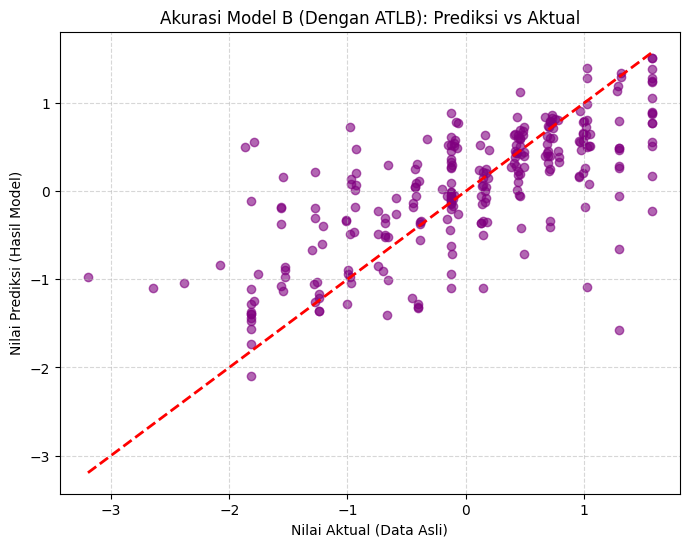

In [ ]:
hasil_prediksi_b = pd.DataFrame({
    'Aktual': y_test_b,
    'Prediksi': y_pred_b,
    'Selisih (Error)': y_test_b - y_pred_b
})

print("\n--- 10 Sampel Prediksi Model B (Dengan Mediator ATLB) ---")
print(hasil_prediksi_b.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_b['Aktual'], hasil_prediksi_b['Prediksi'], alpha=0.6, color='purple')
plt.plot([hasil_prediksi_b['Aktual'].min(), hasil_prediksi_b['Aktual'].max()],
         [hasil_prediksi_b['Aktual'].min(), hasil_prediksi_b['Aktual'].max()], 'r--', lw=2)

plt.xlabel('Nilai Aktual (Data Asli)')
plt.ylabel('Nilai Prediksi (Hasil Model)')
plt.title('Akurasi Model B (Dengan ATLB): Prediksi vs Aktual')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## BAYESIAN RIDGE REGRESSION

In [ ]:
def process_bayesian_model(features, target_col, df, model_name):
    X = df[features]
    y = df[target_col]

    # Split 70% Train, 30% Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Bayesian Ridge sangat sensitif terhadap skala, jadi kita gunakan StandardScaler
    model = make_pipeline(
        StandardScaler(), # Mengubah data sehingga setiap fitur memiliki rata-rata 0 dan standar deviasi 1 (normalisasi)
        BayesianRidge()   # Menggabungkan proses penskalaan dan pemodelan menjadi satu kesatuan.
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE' : mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }
    return results, model, X_test, y_test, y_pred

In [ ]:
res_br_a, model_br_a, X_test_a, y_test_a, y_pred_a = process_bayesian_model(features_a, target, df, "Bayesian Model A")
res_br_b, model_br_b, X_test_b, y_test_b, y_pred_b = process_bayesian_model(features_b, target, df, "Bayesian Model B")

# Menampilkan Hasil Performa
df_br_results = pd.DataFrame([res_br_a, res_br_b])
print("\n==========================================")
print("Perbandingan Performa Bayesian Ridge:")
print("==========================================")
print(df_br_results)


Perbandingan Performa Bayesian Ridge:
              Model      RMSE       MAE        R2
0  Bayesian Model A  0.811017  0.621768  0.302276
1  Bayesian Model B  0.767285  0.576833  0.375492


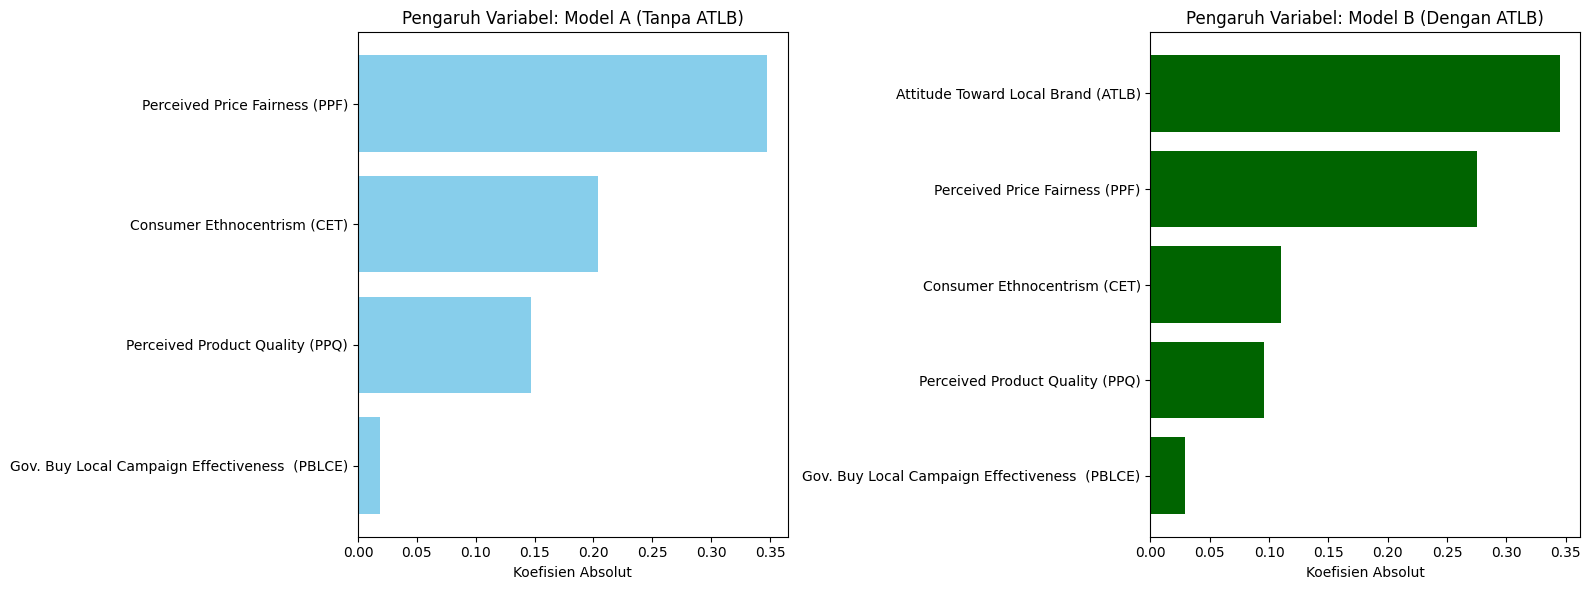

In [ ]:
br_model_a = model_br_a.named_steps['bayesianridge']
br_model_b = model_br_b.named_steps['bayesianridge']

# 2. Membuat DataFrame untuk perbandingan koefisien
importance_a = pd.DataFrame({'Feature': features_a, 'Importance': np.abs(br_model_a.coef_)})
importance_b = pd.DataFrame({'Feature': features_b, 'Importance': np.abs(br_model_b.coef_)})

# 3. Visualisasi Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Model A
axes[0].barh(importance_a.sort_values('Importance')['Feature'],
             importance_a.sort_values('Importance')['Importance'], color='skyblue')
axes[0].set_title('Pengaruh Variabel: Model A (Tanpa ATLB)')
axes[0].set_xlabel('Koefisien Absolut')

# Plot Model B
axes[1].barh(importance_b.sort_values('Importance')['Feature'],
             importance_b.sort_values('Importance')['Importance'], color='darkgreen')
axes[1].set_title('Pengaruh Variabel: Model B (Dengan ATLB)')
axes[1].set_xlabel('Koefisien Absolut')

plt.tight_layout()
plt.show()


--- 10 Sampel Prediksi Bayesian Model A (Tanpa Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
70  -0.929547  0.256918        -1.186465
827  1.573347  0.174758         1.398589
231 -0.111096  0.227943        -0.339038
588 -0.680170 -0.329590        -0.350579
39  -0.070657  0.227172        -0.297829
731 -0.123198  0.169652        -0.292851
299  0.112650  0.405847        -0.293196
110 -1.867044  0.506107        -2.373152
72  -0.993911 -0.847914        -0.145997
86   1.011655 -1.569176         2.580830


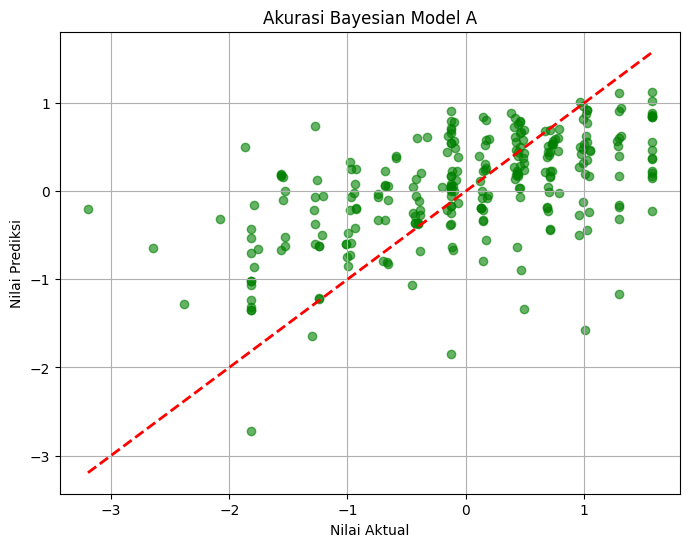

In [ ]:
hasil_prediksi_br_a = pd.DataFrame({
    'Aktual': y_test_a,
    'Prediksi': y_pred_a,
    'Selisih (Error)': y_test_a - y_pred_a
})
print("\n--- 10 Sampel Prediksi Bayesian Model A (Tanpa Mediator ATLB) ---")
print(hasil_prediksi_br_a.head(10)) # Menggunakan head(10) agar terminal tidak penuh

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_br_a['Aktual'], hasil_prediksi_br_a['Prediksi'], alpha=0.6, color='green')
plt.plot([hasil_prediksi_br_a['Aktual'].min(), hasil_prediksi_br_a['Aktual'].max()],
         [hasil_prediksi_br_a['Aktual'].min(), hasil_prediksi_br_a['Aktual'].max()], 'r--', lw=2)

plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi Bayesian Model A')
plt.grid(True)
plt.show()


--- 10 Sampel Prediksi Bayesian Model B (Dengan Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
70  -0.929547  0.128786        -1.058333
827  1.573347  0.352425         1.220922
231 -0.111096 -0.092707        -0.018389
588 -0.680170 -0.430896        -0.249274
39  -0.070657  0.656456        -0.727113
731 -0.123198  0.037786        -0.160985
299  0.112650  0.257931        -0.145281
110 -1.867044  0.188752        -2.055796
72  -0.993911 -0.218619        -0.775292
86   1.011655 -0.642611         1.654265


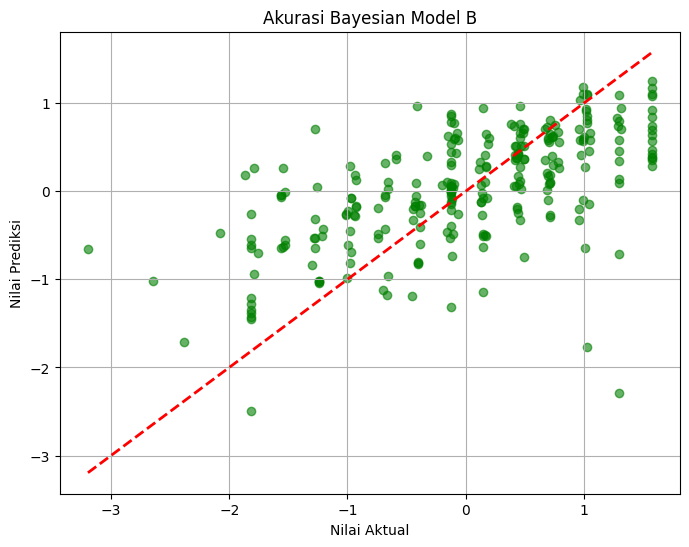

In [ ]:
hasil_prediksi_br_b = pd.DataFrame({
    'Aktual': y_test_b,
    'Prediksi': y_pred_b,
    'Selisih (Error)': y_test_b - y_pred_b
})
print("\n--- 10 Sampel Prediksi Bayesian Model B (Dengan Mediator ATLB) ---")
print(hasil_prediksi_br_b.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_br_b['Aktual'], hasil_prediksi_br_b['Prediksi'], alpha=0.6, color='green')
plt.plot([hasil_prediksi_br_b['Aktual'].min(), hasil_prediksi_br_b['Aktual'].max()],
         [hasil_prediksi_br_b['Aktual'].min(), hasil_prediksi_br_b['Aktual'].max()], 'r--', lw=2)

plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi Bayesian Model B')
plt.grid(True)
plt.show()

## ELASTIC NET REGRESSION

In [ ]:
def process_elastic_net(features, target_col, df, model_name):
    X = df[features]
    y = df[target_col]

    # Split data 70:30
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Pipeline: Standarisasi + Model
    pipeline = make_pipeline(StandardScaler(), ElasticNet(random_state=42))

    # Grid Search untuk mencari kombinasi parameter terbaik
    param_grid = {
        'elasticnet__alpha': [0.001, 0.01, 0.1, 1, 10],
        'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    }

    grid = GridSearchCV(pipeline, param_grid, cv=10, scoring='neg_mean_squared_error')
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    # Simpan hasil metrik
    results = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

    return results, best_model, X_test, y_test

In [ ]:
res_a, model_a, X_test_a, y_test_a = process_elastic_net(features_a, target, df, "Model A (Elastic Net)")
res_b, model_b, X_test_b, y_test_b = process_elastic_net(features_b, target, df, "Model B (Elastic Net)")

# Menampilkan perbandingan
df_results = pd.DataFrame([res_a, res_b])
print(df_results)

                   Model      RMSE       MAE        R2
0  Model A (Elastic Net)  0.811090  0.621450  0.302150
1  Model B (Elastic Net)  0.768875  0.580227  0.372901


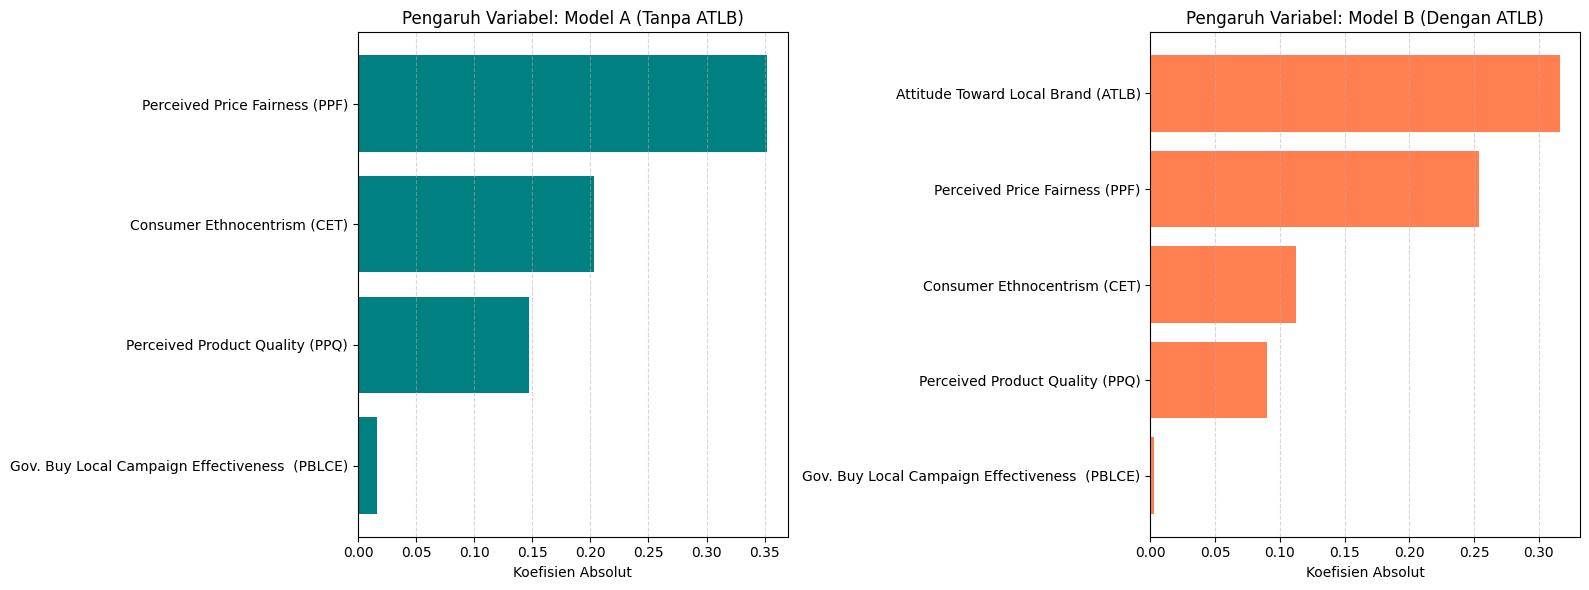

In [ ]:
# 1. Mengambil model Elastic Net dari masing-masing pipeline
# Pastikan nama step sesuai dengan nama yang diberikan di pipeline atau default-nya
en_model_a = model_a.named_steps['elasticnet']
en_model_b = model_b.named_steps['elasticnet']

# 2. Membuat DataFrame untuk perbandingan koefisien
# Nilai koefisien absolut menunjukkan kekuatan pengaruh (semakin besar semakin berpengaruh)
importance_a = pd.DataFrame({'Feature': features_a, 'Importance': np.abs(en_model_a.coef_)})
importance_b = pd.DataFrame({'Feature': features_b, 'Importance': np.abs(en_model_b.coef_)})

# 3. Visualisasi Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Model A
axes[0].barh(importance_a.sort_values('Importance')['Feature'],
             importance_a.sort_values('Importance')['Importance'], color='teal')
axes[0].set_title('Pengaruh Variabel: Model A (Tanpa ATLB)')
axes[0].set_xlabel('Koefisien Absolut')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Plot Model B
axes[1].barh(importance_b.sort_values('Importance')['Feature'],
             importance_b.sort_values('Importance')['Importance'], color='coral')
axes[1].set_title('Pengaruh Variabel: Model B (Dengan ATLB)')
axes[1].set_xlabel('Koefisien Absolut')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

--- Sampel Prediksi Elastic Net Model A (Tanpa Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
70  -0.929547  0.257938        -1.187485
827  1.573347  0.170065         1.403282
231 -0.111096  0.233450        -0.344546
588 -0.680170 -0.331908        -0.348262
39  -0.070657  0.227513        -0.298170
731 -0.123198  0.168014        -0.291213
299  0.112650  0.409631        -0.296981
110 -1.867044  0.507664        -2.374709
72  -0.993911 -0.857608        -0.136303
86   1.011655 -1.585959         2.597613


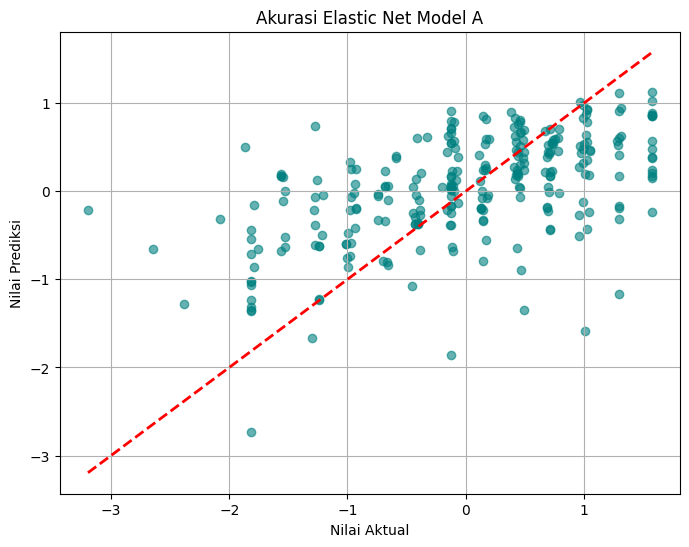

In [ ]:
hasil_prediksi_en_a = pd.DataFrame({
    'Aktual': y_test_a,
    'Prediksi': model_a.predict(X_test_a),
    'Selisih (Error)': y_test_a - model_a.predict(X_test_a)
})
print("--- Sampel Prediksi Elastic Net Model A (Tanpa Mediator ATLB) ---")
print(hasil_prediksi_en_a.head(10))

# Plot Scatter Model A
plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_en_a['Aktual'], hasil_prediksi_en_a['Prediksi'], alpha=0.6, color='teal')
plt.plot([hasil_prediksi_en_a['Aktual'].min(), hasil_prediksi_en_a['Aktual'].max()],
         [hasil_prediksi_en_a['Aktual'].min(), hasil_prediksi_en_a['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi Elastic Net Model A')
plt.grid(True)
plt.show()


--- Sampel Prediksi Elastic Net Model B (Dengan Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
70  -0.929547  0.132989        -1.062536
827  1.573347  0.371041         1.202306
231 -0.111096 -0.105752        -0.005344
588 -0.680170 -0.429717        -0.250453
39  -0.070657  0.624829        -0.695486
731 -0.123198  0.054817        -0.178015
299  0.112650  0.249982        -0.137331
110 -1.867044  0.197719        -2.064764
72  -0.993911 -0.186777        -0.807134
86   1.011655 -0.592241         1.603895


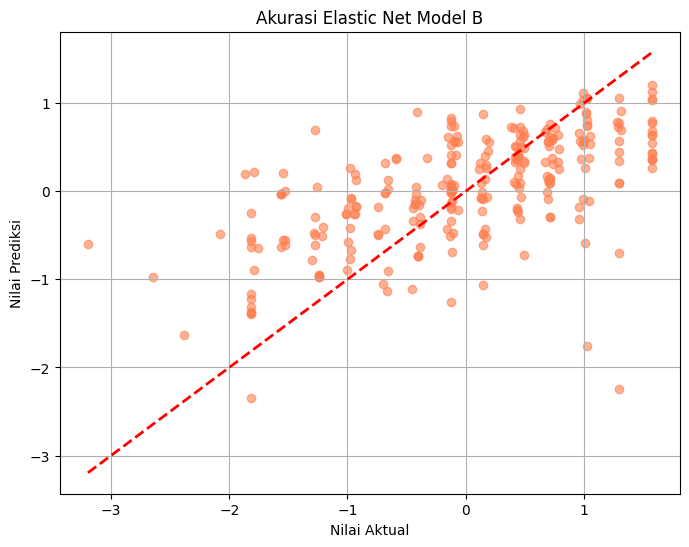

In [ ]:
hasil_prediksi_en_b = pd.DataFrame({
    'Aktual': y_test_b,
    'Prediksi': model_b.predict(X_test_b),
    'Selisih (Error)': y_test_b - model_b.predict(X_test_b)
})
print("\n--- Sampel Prediksi Elastic Net Model B (Dengan Mediator ATLB) ---")
print(hasil_prediksi_en_b.head(10))

# Plot Scatter Model B
plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_en_b['Aktual'], hasil_prediksi_en_b['Prediksi'], alpha=0.6, color='coral')
plt.plot([hasil_prediksi_en_b['Aktual'].min(), hasil_prediksi_en_b['Aktual'].max()],
         [hasil_prediksi_en_b['Aktual'].min(), hasil_prediksi_en_b['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi Elastic Net Model B')
plt.grid(True)
plt.show()

## XGBOOST

In [ ]:
def process_xgboost(features, target_col, df, model_name):
    X = df[features]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # XGBoost tidak memerlukan Standard Scaler
    model = XGBRegressor(random_state=42, objective='reg:squarederror')

    # Grid Search untuk hyperparameter XGBoost
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }

    grid = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    results = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }
    return results, best_model, X_test, y_test, y_pred

In [ ]:
res_xgb_a, model_xgb_a, X_test_xgb_a, y_test_xgb_a, y_pred_xgb_a = process_xgboost(features_a, target, df, "XGBoost - Model A")
res_xgb_b, model_xgb_b, X_test_xgb_b, y_test_xgb_b, y_pred_xgb_b = process_xgboost(features_b, target, df, "XGBoost - Model B")

df_results = pd.DataFrame([res_xgb_a, res_xgb_b])
print(df_results)

               Model      RMSE       MAE        R2
0  XGBoost - Model A  0.724149  0.541267  0.443737
1  XGBoost - Model B  0.699481  0.542584  0.480989


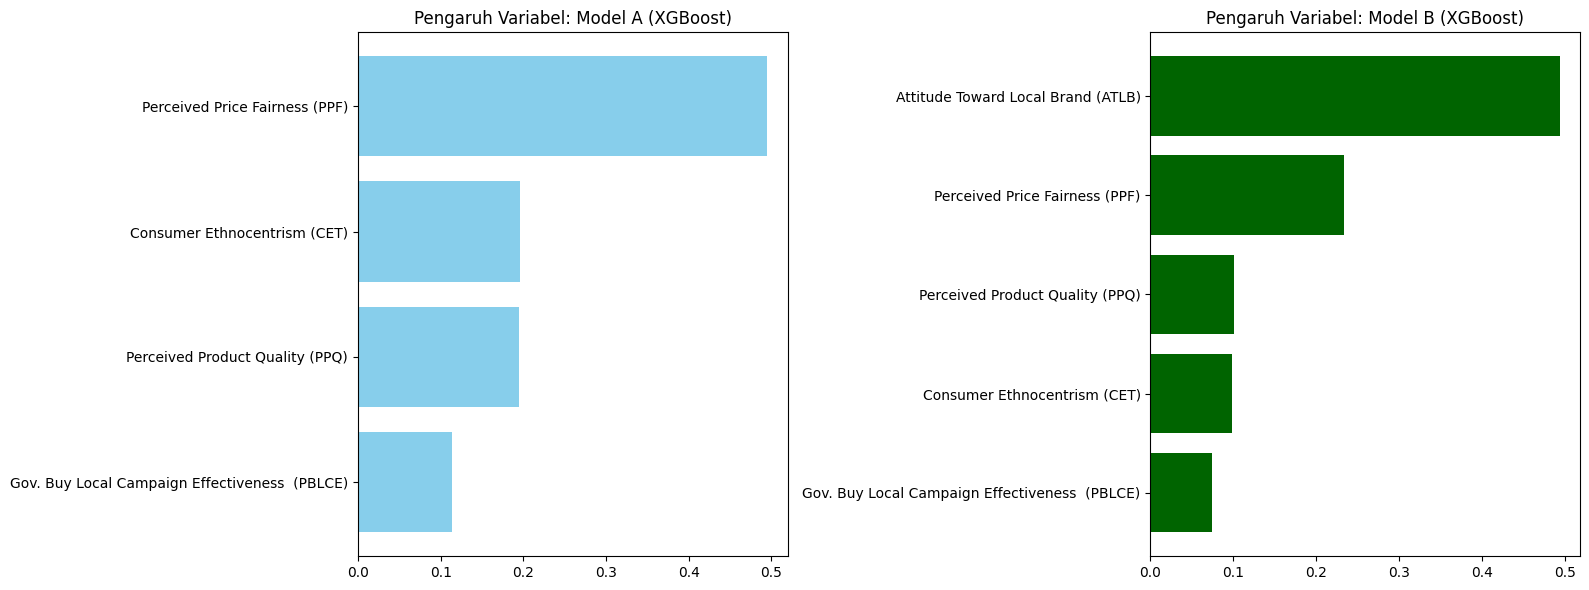

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (model, feat, title, color) in enumerate([(model_xgb_a, features_a, 'Model A', 'skyblue'),
                                                 (model_xgb_b, features_b, 'Model B', 'darkgreen')]):
    importance = pd.DataFrame({'Feature': feat, 'Importance': model.feature_importances_})
    importance = importance.sort_values('Importance', ascending=True)

    axes[i].barh(importance['Feature'], importance['Importance'], color=color)
    axes[i].set_title(f'Pengaruh Variabel: {title} (XGBoost)')

plt.tight_layout()
plt.show()

--- Sampel Prediksi XGBoost Model A (Tanpa Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
70  -0.929547  0.418557        -1.348104
827  1.573347  0.907389         0.665958
231 -0.111096  0.298914        -0.410010
588 -0.680170 -0.010063        -0.670107
39  -0.070657  0.384066        -0.454723
731 -0.123198  0.007439        -0.130637
299  0.112650  0.608994        -0.496344
110 -1.867044  0.519819        -2.386864
72  -0.993911 -1.014993         0.021082
86   1.011655 -0.126031         1.137686


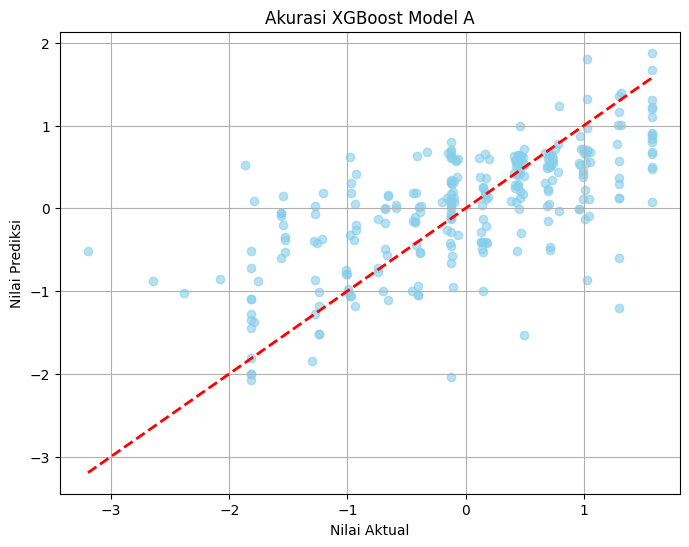

In [ ]:
hasil_prediksi_xgb_a = pd.DataFrame({
    'Aktual': y_test_xgb_a,
    'Prediksi': model_xgb_a.predict(X_test_xgb_a),
    'Selisih (Error)': y_test_xgb_a - model_xgb_a.predict(X_test_xgb_a)
})
print("--- Sampel Prediksi XGBoost Model A (Tanpa Mediator ATLB) ---")
print(hasil_prediksi_xgb_a.head(10))

# Plot Scatter Model A
plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_xgb_a['Aktual'], hasil_prediksi_xgb_a['Prediksi'], alpha=0.6, color='skyblue')
plt.plot([hasil_prediksi_xgb_a['Aktual'].min(), hasil_prediksi_xgb_a['Aktual'].max()],
         [hasil_prediksi_xgb_a['Aktual'].min(), hasil_prediksi_xgb_a['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi XGBoost Model A')
plt.grid(True)
plt.show()


--- Sampel Prediksi XGBoost Model B (Dengan Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
70  -0.929547  0.428830        -1.358378
827  1.573347  0.594740         0.978607
231 -0.111096  0.259715        -0.370811
588 -0.680170 -0.464615        -0.215555
39  -0.070657  0.556558        -0.627215
731 -0.123198  0.036073        -0.159271
299  0.112650  0.418371        -0.305721
110 -1.867044  0.193283        -2.060327
72  -0.993911 -0.872927        -0.120984
86   1.011655 -0.068692         1.080346


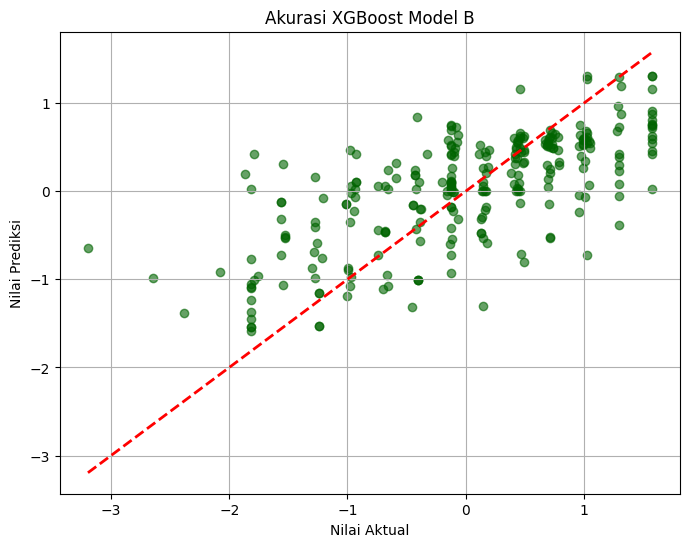

In [ ]:
hasil_prediksi_xgb_b = pd.DataFrame({
    'Aktual': y_test_xgb_b,
    'Prediksi': model_xgb_b.predict(X_test_xgb_b),
    'Selisih (Error)': y_test_xgb_b - model_xgb_b.predict(X_test_xgb_b)
})
print("\n--- Sampel Prediksi XGBoost Model B (Dengan Mediator ATLB) ---")
print(hasil_prediksi_xgb_b.head(10))

# Plot Scatter Model B
plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_xgb_b['Aktual'], hasil_prediksi_xgb_b['Prediksi'], alpha=0.6, color='darkgreen')
plt.plot([hasil_prediksi_xgb_b['Aktual'].min(), hasil_prediksi_xgb_b['Aktual'].max()],
         [hasil_prediksi_xgb_b['Aktual'].min(), hasil_prediksi_xgb_b['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi XGBoost Model B')
plt.grid(True)
plt.show()

## GAUSSIAN PROCESS REGRESSOR

In [ ]:
def process_gpr_model(features, target_col, df, model_name):
    X = df[features]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # GPR sangat sensitif terhadap skala
    kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
    model = make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(kernel=kernel, random_state=42, n_restarts_optimizer=5)
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE' : mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }
    return results, model, X_test, y_test, y_pred

In [ ]:
res_gpr_a, model_gpr_a, X_test_a, y_test_a, y_pred_a = process_gpr_model(features_a, target, df, "GPR Model A")
res_gpr_b, model_gpr_b, X_test_b, y_test_b, y_pred_b = process_gpr_model(features_b, target, df, "GPR Model B")

# Menampilkan Hasil Performa
df_gpr_results = pd.DataFrame([res_gpr_a, res_gpr_b])
print("Perbandingan Performa GPR:")
print(df_gpr_results)

Perbandingan Performa GPR:
         Model      RMSE       MAE        R2
0  GPR Model A  0.762181  0.577697  0.383773
1  GPR Model B  0.729598  0.561652  0.435334


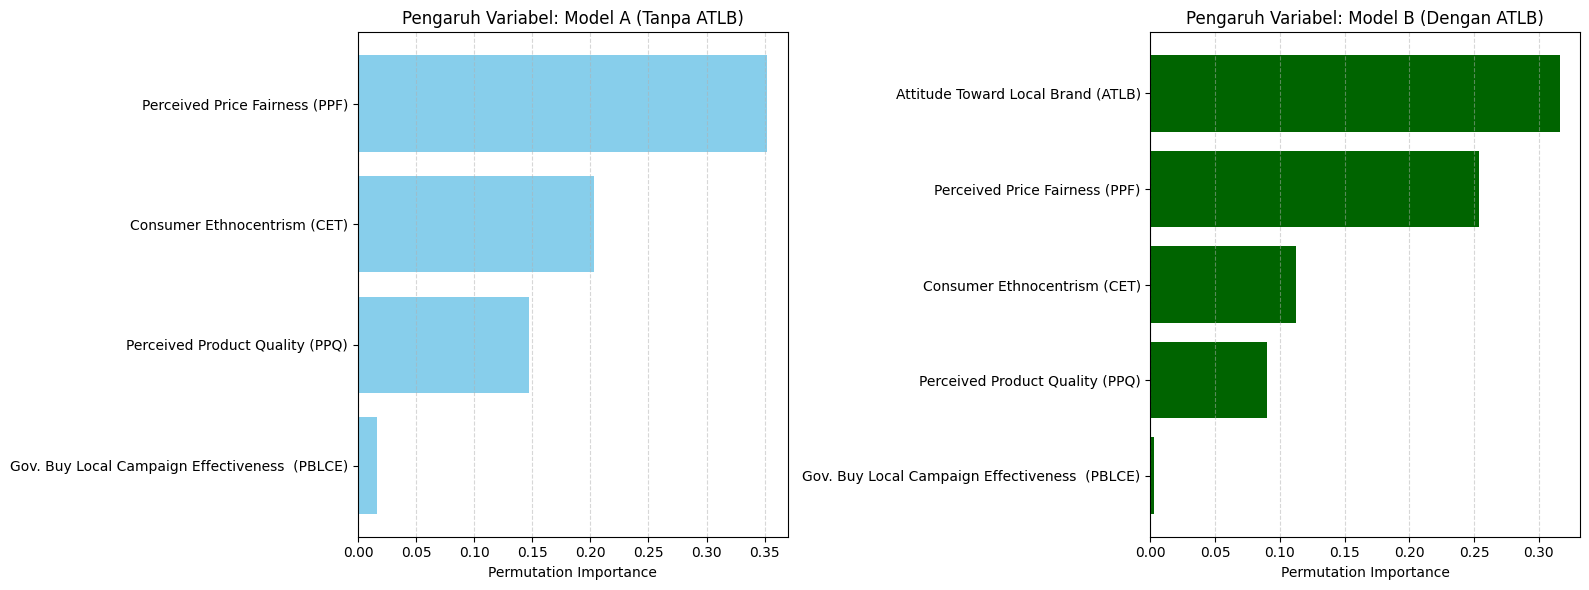

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Model A
importance_a_sorted = importance_a.sort_values('Importance', ascending=True)
axes[0].barh(importance_a_sorted['Feature'], importance_a_sorted['Importance'], color='skyblue')
axes[0].set_title('Pengaruh Variabel: Model A (Tanpa ATLB)')
axes[0].set_xlabel('Permutation Importance')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Plot Model B
importance_b_sorted = importance_b.sort_values('Importance', ascending=True)
axes[1].barh(importance_b_sorted['Feature'], importance_b_sorted['Importance'], color='darkgreen')
axes[1].set_title('Pengaruh Variabel: Model B (Dengan ATLB)')
axes[1].set_xlabel('Permutation Importance')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

--- Sampel Prediksi GPR Model A (Tanpa Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
70  -0.929547  0.444277        -1.373824
827  1.573347 -0.084027         1.657374
231 -0.111096  0.341833        -0.452928
588 -0.680170 -0.104761        -0.575409
39  -0.070657  0.295275        -0.365932
731 -0.123198  0.173512        -0.296711
299  0.112650  0.612474        -0.499824
110 -1.867044  0.591268        -2.458313
72  -0.993911 -0.877662        -0.116249
86   1.011655 -0.942271         1.953926


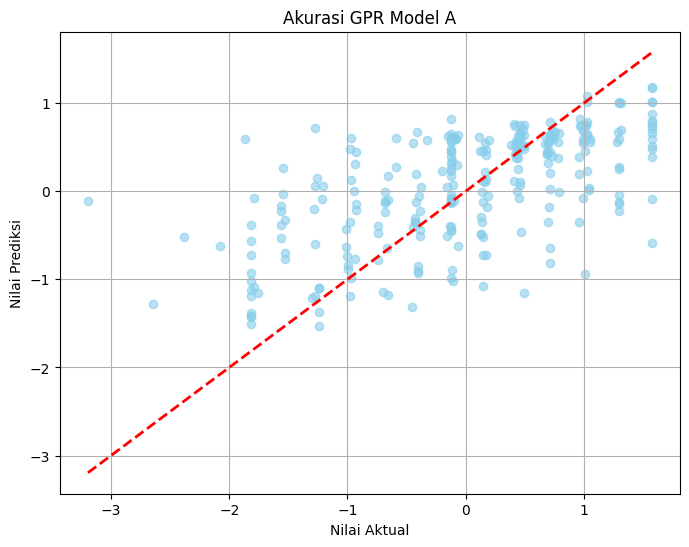

In [ ]:
hasil_prediksi_gpr_a = pd.DataFrame({
    'Aktual': y_test_a,
    'Prediksi': y_pred_a,
    'Selisih (Error)': y_test_a - y_pred_a
})

print("--- Sampel Prediksi GPR Model A (Tanpa Mediator ATLB) ---")
print(hasil_prediksi_gpr_a.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_gpr_a['Aktual'], hasil_prediksi_gpr_a['Prediksi'], alpha=0.6, color='skyblue')
plt.plot([hasil_prediksi_gpr_a['Aktual'].min(), hasil_prediksi_gpr_a['Aktual'].max()],
         [hasil_prediksi_gpr_a['Aktual'].min(), hasil_prediksi_gpr_a['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi GPR Model A')
plt.grid(True)
plt.show()


--- Sampel Prediksi GPR Model B (Dengan Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407 -0.117601 -0.643886         0.526284
444 -0.299373  0.586262        -0.885635
117 -0.117601  0.132461        -0.250063
30   0.393104  0.494587        -0.101482
415  1.530275  1.062030         0.468244
157 -1.190307  0.787026        -1.977333
325  0.942427  0.650911         0.291516
447  0.012334  0.659112        -0.646778
268  0.406043  0.053330         0.352714
297  0.176265  0.541917        -0.365652


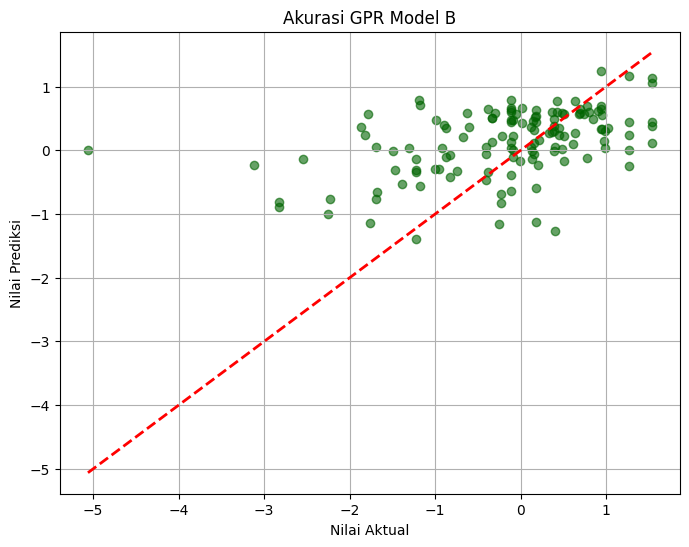

In [ ]:
hasil_prediksi_gpr_b = pd.DataFrame({
    'Aktual': y_test_b,
    'Prediksi': y_pred_b,
    'Selisih (Error)': y_test_b - y_pred_b
})

print("\n--- Sampel Prediksi GPR Model B (Dengan Mediator ATLB) ---")
print(hasil_prediksi_gpr_b.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_gpr_b['Aktual'], hasil_prediksi_gpr_b['Prediksi'], alpha=0.6, color='darkgreen')
plt.plot([hasil_prediksi_gpr_b['Aktual'].min(), hasil_prediksi_gpr_b['Aktual'].max()],
         [hasil_prediksi_gpr_b['Aktual'].min(), hasil_prediksi_gpr_b['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi GPR Model B')
plt.grid(True)
plt.show()

# 450 (GEN Y)

## IMPORT (GEN Y)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import requests
import io
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.preprocessing import PolynomialFeatures

## PRE PROCESSING (GEN Y)

In [ ]:
urly = "https://raw.githubusercontent.com/hqq24/project/refs/heads/main/data%20gen%20Y%20(1).csv"
response = requests.get(urly)
content = response.content.decode('utf-8')

# Gunakan StringIO untuk membaca file dan skip baris yang tidak perlu
dfy = pd.read_csv(io.StringIO(content), skiprows=5)

# Bersihkan nama kolom
dfy.columns = dfy.columns.str.strip()

# Hapus kolom yang tidak bernama
dfy = dfy.loc[:, ~dfy.columns.str.contains('^Unnamed')]

# Hapus baris kosong
dfy = dfy.dropna(how='all')

print(f"Jumlah baris data: {dfy.shape[0]}")
print("\nPreview Data:")
print(dfy.head())

Jumlah baris data: 450

Preview Data:
   Case ID  Attitude Toward Local Brand (ATLB)  Consumer Ethnocentrism (CET)  \
0        1                            0.235141                      1.015136   
1        2                            0.416492                      0.345119   
2        3                            0.399630                      0.920571   
3        4                            0.665571                     -1.080070   
4        5                            0.938680                      0.345119   

   Gov. Buy Local Campaign Effectiveness (PBLCE)  \
0                                       0.432232   
1                                       0.352355   
2                                       0.461882   
3                                       0.201016   
4                                       0.398620   

   Local Fashion Brand Love (LFBL)  Perceived Price Fairness (PPF)  \
0                         0.850422                        0.922763   
1                         0.

In [ ]:
# pembagian Model A
features_a = ['Perceived Product Quality (PPQ)',
              'Perceived Price Fairness (PPF)',
              'Gov. Buy Local Campaign Effectiveness (PBLCE)',
              'Consumer Ethnocentrism (CET)']

# pembagian Model B
features_b = features_a + ['Attitude Toward Local Brand (ATLB)']

# variabel target
target = 'Local Fashion Brand Love (LFBL)'

In [ ]:
poly_a = PolynomialFeatures(degree=2, include_bias=False)
X_poly_a = poly_a.fit_transform(dfy[features_a])
# PERBAIKAN: Menggunakan get_feature_names_out agar nama fitur aslinya terbawa
poly_cols_a = poly_a.get_feature_names_out(features_a)
df_poly_a = pd.DataFrame(X_poly_a, columns=poly_cols_a, index=dfy.index)

# Polynomial Features Model B
poly_b = PolynomialFeatures(degree=2, include_bias=False)
X_poly_b = poly_b.fit_transform(dfy[features_b])
# PERBAIKAN: Sama untuk Model B
poly_cols_b = poly_b.get_feature_names_out(features_b)
df_poly_b = pd.DataFrame(X_poly_b, columns=poly_cols_b, index=dfy.index)

# Menggabungkan fitur polynomial ke dataframe asli
df_model_a = df_poly_a.copy()
df_model_a[target] = dfy[target] # Hanya memasukkan kolom 'Local Fashion Brand Love (LFBL)'

df_model_b = df_poly_b.copy()
df_model_b[target] = dfy[target]

## RANDOM FOREST (GEN Y)

In [ ]:
def process_rf_model_engineered(features_list, target_col, df_source, model_name):
    # Menggunakan kolom hasil feature engineering
    X = df_source[features_list]
    y = df_source[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    param_grid = {
        'n_estimators': [300, 500],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    }

    grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)

    print(f"Sedang melatih {model_name} dengan Polynomial Features...")
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    results = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

    # PERBAIKAN: Kembalikan model, test set, dan prediksi agar bisa divisualisasikan nanti
    return results, best_model, X_test, y_test, y_pred

In [ ]:
try:
    # Mengambil nilai kembalian (return) dari fungsi
    res_a, model_a, X_test_a, y_test_a, y_pred_a = process_rf_model_engineered(
        poly_cols_a, target, df_model_a, "Model A (Polynomial)")
    res_b, model_b, X_test_b, y_test_b, y_pred_b = process_rf_model_engineered(
        poly_cols_b, target, df_model_b, "Model B (Polynomial)")

    df_results = pd.DataFrame([res_a, res_b])

    print("\n--- Perbandingan Performa Akhir ---")
    print(df_results)
except Exception as e:
    print(f"\nTerjadi Kesalahan saat melatih model: {e}")

Sedang melatih Model A (Polynomial) dengan Polynomial Features...
Sedang melatih Model B (Polynomial) dengan Polynomial Features...

--- Perbandingan Performa Akhir ---
                  Model      RMSE       MAE        R2
0  Model A (Polynomial)  0.970998  0.714187  0.175498
1  Model B (Polynomial)  0.921318  0.675111  0.257711



Membuat Visualisasi Permutation Importance...


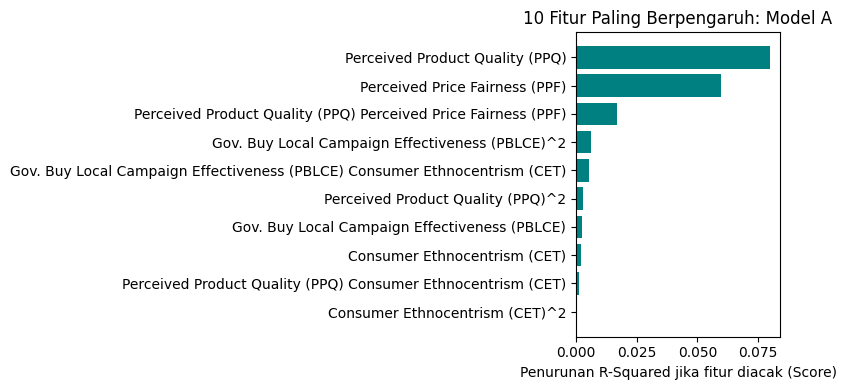

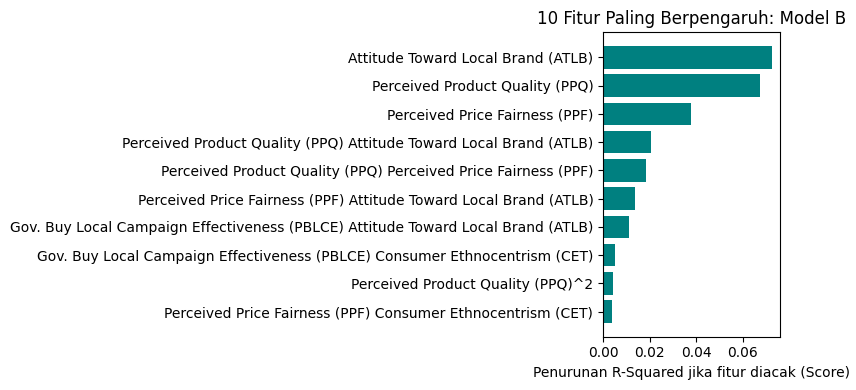

In [ ]:
def plot_importance(model, features, X_test, y_test, name):
    perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='r2')

    importance_df = pd.DataFrame({'Feature': features, 'Importance': perm_importance.importances_mean})
    importance_df = importance_df.sort_values(by='Importance', ascending=True)

    # Menampilkan hanya 10 fitur terpenting agar grafik tidak terlalu padat
    importance_df = importance_df.tail(10)

    plt.figure(figsize=(8, 4))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
    plt.title(f'10 Fitur Paling Berpengaruh: {name}')
    plt.xlabel('Penurunan R-Squared jika fitur diacak (Score)')
    plt.tight_layout()
    plt.show()

print("\nMembuat Visualisasi Permutation Importance...")
# PERBAIKAN: Menggunakan poly_cols_a/b sebagai features list, BUKAN features_a/b
plot_importance(model_a, poly_cols_a, X_test_a, y_test_a, "Model A")
plot_importance(model_b, poly_cols_b, X_test_b, y_test_b, "Model B")


--- 10 Sampel Prediksi Model A (Tanpa Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407 -0.117601 -0.768749         0.651148
444 -0.299373  0.616572        -0.915945
117 -0.117601  0.472119        -0.589720
30   0.393104  0.545109        -0.152004
415  1.530275  1.166432         0.363843
157 -1.190307  0.643784        -1.834092
325  0.942427  0.530355         0.412072
447  0.012334  0.533918        -0.521583
268  0.406043 -0.611711         1.017754
297  0.176265  0.743443        -0.567179


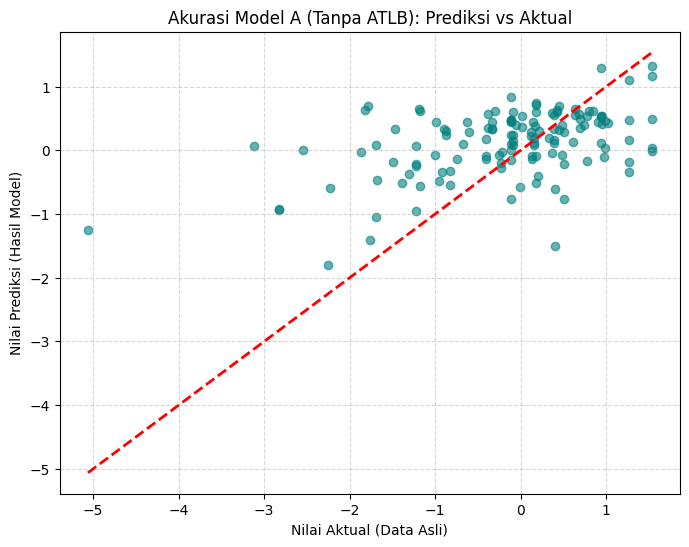

In [ ]:
hasil_prediksi_a = pd.DataFrame({
    'Aktual': y_test_a,
    'Prediksi': y_pred_a,
    'Selisih (Error)': y_test_a - y_pred_a
})

print("\n--- 10 Sampel Prediksi Model A (Tanpa Mediator ATLB) ---")
print(hasil_prediksi_a.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_a['Aktual'], hasil_prediksi_a['Prediksi'], alpha=0.6, color='teal')
plt.plot([hasil_prediksi_a['Aktual'].min(), hasil_prediksi_a['Aktual'].max()],
         [hasil_prediksi_a['Aktual'].min(), hasil_prediksi_a['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual (Data Asli)')
plt.ylabel('Nilai Prediksi (Hasil Model)')
plt.title('Akurasi Model A (Tanpa ATLB): Prediksi vs Aktual')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


--- 10 Sampel Prediksi Model B (Dengan Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407 -0.117601 -0.129877         0.012275
444 -0.299373  0.587318        -0.886691
117 -0.117601  0.309561        -0.427163
30   0.393104  0.502419        -0.109315
415  1.530275  1.140475         0.389800
157 -1.190307  0.672385        -1.862692
325  0.942427  0.621590         0.320837
447  0.012334  0.579915        -0.567581
268  0.406043 -0.872018         1.278061
297  0.176265  0.749798        -0.573533


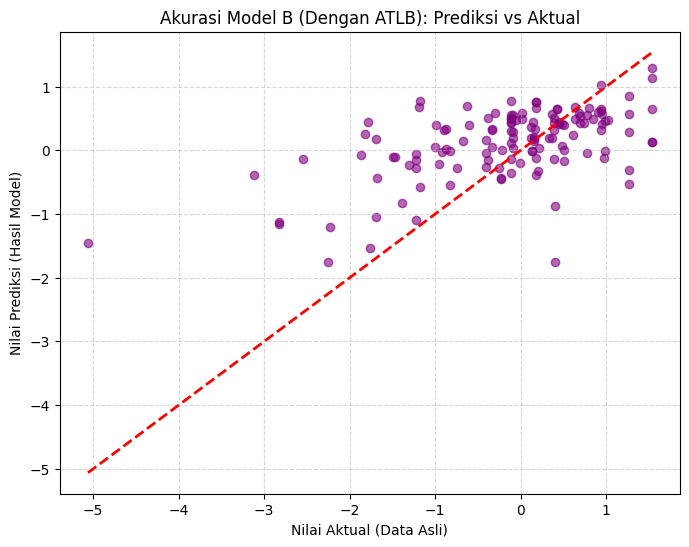

In [ ]:
hasil_prediksi_b = pd.DataFrame({
    'Aktual': y_test_b,
    'Prediksi': y_pred_b,
    'Selisih (Error)': y_test_b - y_pred_b
})

print("\n--- 10 Sampel Prediksi Model B (Dengan Mediator ATLB) ---")
print(hasil_prediksi_b.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_b['Aktual'], hasil_prediksi_b['Prediksi'], alpha=0.6, color='purple')
plt.plot([hasil_prediksi_b['Aktual'].min(), hasil_prediksi_b['Aktual'].max()],
         [hasil_prediksi_b['Aktual'].min(), hasil_prediksi_b['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual (Data Asli)')
plt.ylabel('Nilai Prediksi (Hasil Model)')
plt.title('Akurasi Model B (Dengan ATLB): Prediksi vs Aktual')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## BAYESIAN RIDGE REGRESSION (GEN Y)

In [ ]:
def process_bayesian_model(features, target_col, df, model_name):
    X = df[features]
    y = df[target_col]

    # Split 70% Train, 30% Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Bayesian Ridge menggunakan StandardScaler di dalam Pipeline
    model = make_pipeline(
        StandardScaler(),
        BayesianRidge()
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE' : mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }
    return results, model, X_test, y_test, y_pred

In [ ]:
res_br_a, model_br_a, X_test_a, y_test_a, y_pred_a = process_bayesian_model(poly_cols_a, target, df_model_a, "Bayesian Model A")
res_br_b, model_br_b, X_test_b, y_test_b, y_pred_b = process_bayesian_model(poly_cols_b, target, df_model_b, "Bayesian Model B")

df_br_results = pd.DataFrame([res_br_a, res_br_b])
print("\n--- Perbandingan Performa Bayesian Ridge ---")
print(df_br_results)


--- Perbandingan Performa Bayesian Ridge ---
              Model      RMSE       MAE        R2
0  Bayesian Model A  0.945663  0.704377  0.217963
1  Bayesian Model B  0.893042  0.676417  0.302574


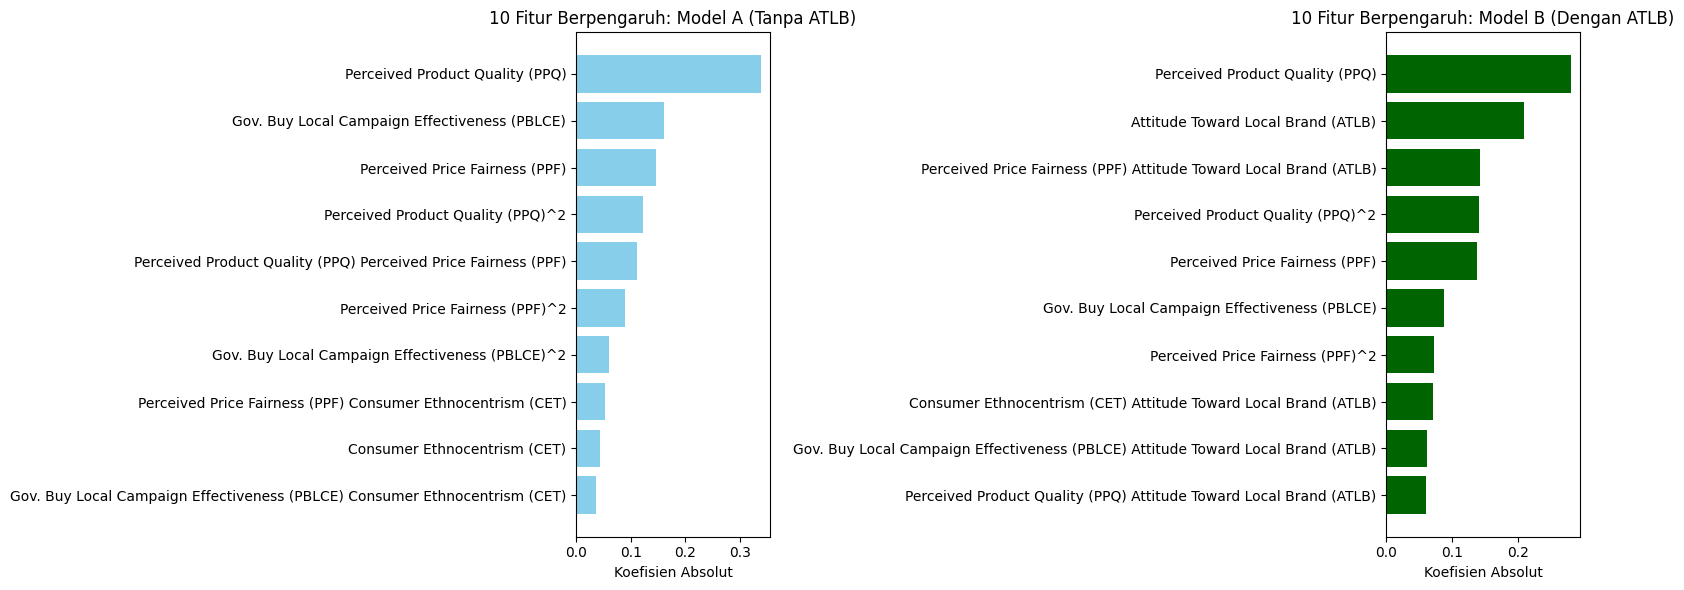

In [ ]:
br_model_a = model_br_a.named_steps['bayesianridge']
br_model_b = model_br_b.named_steps['bayesianridge']

# Membuat DataFrame untuk perbandingan koefisien absolut
importance_a = pd.DataFrame({'Feature': poly_cols_a, 'Importance': np.abs(br_model_a.coef_)})
importance_b = pd.DataFrame({'Feature': poly_cols_b, 'Importance': np.abs(br_model_b.coef_)})

# Mengurutkan dan mengambil 10 besar saja agar grafik terbaca
top_10_a = importance_a.sort_values(by='Importance', ascending=True).tail(10)
top_10_b = importance_b.sort_values(by='Importance', ascending=True).tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Model A
axes[0].barh(top_10_a['Feature'], top_10_a['Importance'], color='skyblue')
axes[0].set_title('10 Fitur Berpengaruh: Model A (Tanpa ATLB)')
axes[0].set_xlabel('Koefisien Absolut')

# Plot Model B
axes[1].barh(top_10_b['Feature'], top_10_b['Importance'], color='darkgreen')
axes[1].set_title('10 Fitur Berpengaruh: Model B (Dengan ATLB)')
axes[1].set_xlabel('Koefisien Absolut')

plt.tight_layout()
plt.show()


--- Sampel Prediksi Bayesian Model A (Tanpa Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407 -0.117601 -0.662615         0.545014
444 -0.299373  0.481108        -0.780481
117 -0.117601 -0.007807        -0.109795
30   0.393104  0.526724        -0.133620
415  1.530275  1.002750         0.527525
157 -1.190307  0.504600        -1.694907
325  0.942427  0.462071         0.480356
447  0.012334  0.464733        -0.452399
268  0.406043 -0.989229         1.395272
297  0.176265  0.700585        -0.524320


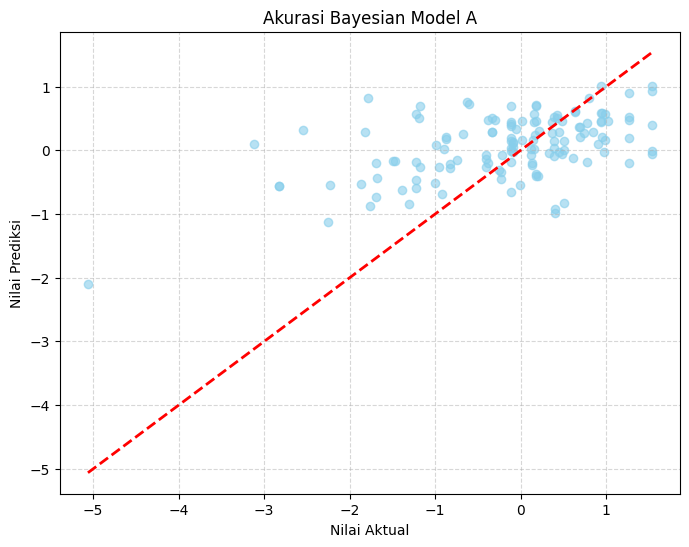

In [ ]:
hasil_prediksi_br_a = pd.DataFrame({
    'Aktual': y_test_a,
    'Prediksi': y_pred_a,
    'Selisih (Error)': y_test_a - y_pred_a
})
print("\n--- Sampel Prediksi Bayesian Model A (Tanpa Mediator ATLB) ---")
print(hasil_prediksi_br_a.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_br_a['Aktual'], hasil_prediksi_br_a['Prediksi'], alpha=0.6, color='skyblue')
plt.plot([hasil_prediksi_br_a['Aktual'].min(), hasil_prediksi_br_a['Aktual'].max()],
         [hasil_prediksi_br_a['Aktual'].min(), hasil_prediksi_br_a['Aktual'].max()], 'r--', lw=2)

plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi Bayesian Model A')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


--- Sampel Prediksi Bayesian Model B (Dengan Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407 -0.117601 -0.403283         0.285682
444 -0.299373  0.477246        -0.776619
117 -0.117601 -0.155657         0.038056
30   0.393104  0.531494        -0.138390
415  1.530275  0.950064         0.580211
157 -1.190307  0.633685        -1.823993
325  0.942427  0.523745         0.418682
447  0.012334  0.539658        -0.527323
268  0.406043 -1.500688         1.906731
297  0.176265  0.704342        -0.528077


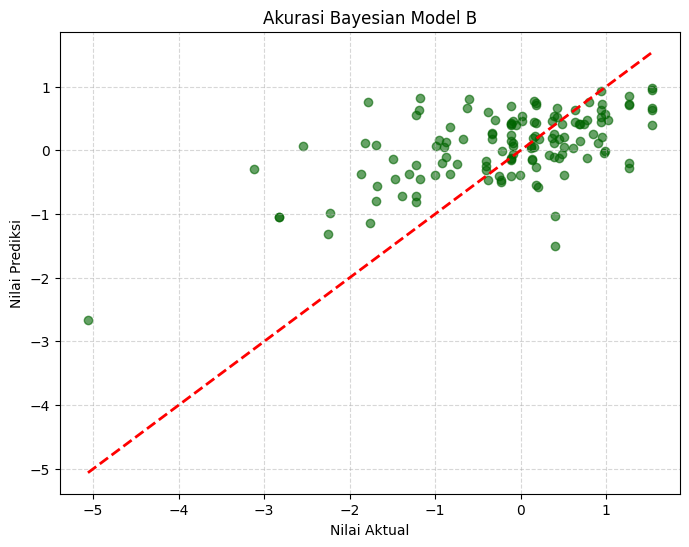

In [ ]:
hasil_prediksi_br_b = pd.DataFrame({
    'Aktual': y_test_b,
    'Prediksi': y_pred_b,
    'Selisih (Error)': y_test_b - y_pred_b
})
print("\n--- Sampel Prediksi Bayesian Model B (Dengan Mediator ATLB) ---")
print(hasil_prediksi_br_b.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_br_b['Aktual'], hasil_prediksi_br_b['Prediksi'], alpha=0.6, color='darkgreen')
plt.plot([hasil_prediksi_br_b['Aktual'].min(), hasil_prediksi_br_b['Aktual'].max()],
         [hasil_prediksi_br_b['Aktual'].min(), hasil_prediksi_br_b['Aktual'].max()], 'r--', lw=2)

plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi Bayesian Model B')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## ELASTIC NET REGRESSION (GEN Y)

In [ ]:
def process_elastic_net(features, target_col, df, model_name):
    X = df[features]
    y = df[target_col]

    # Split data 70:30
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Pipeline: Standarisasi + Model
    pipeline = make_pipeline(StandardScaler(), ElasticNet(random_state=42))

    # Grid Search untuk mencari kombinasi parameter terbaik
    param_grid = {
        'elasticnet__alpha': [0.001, 0.01, 0.1, 1, 10],
        'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    }

    grid = GridSearchCV(pipeline, param_grid, cv=10, scoring='neg_mean_squared_error')
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    # Simpan hasil metrik
    results = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

    # PERBAIKAN: Menambahkan y_pred di nilai kembalian
    return results, best_model, X_test, y_test, y_pred

In [ ]:
res_en_a, model_en_a, X_test_a, y_test_a, y_pred_a = process_elastic_net(poly_cols_a, target, df_model_a, "Model A (Elastic Net)")
res_en_b, model_en_b, X_test_b, y_test_b, y_pred_b = process_elastic_net(poly_cols_b, target, df_model_b, "Model B (Elastic Net)")

# Menampilkan perbandingan performa metrik
df_results = pd.DataFrame([res_en_a, res_en_b])
print("\n--- Perbandingan Performa Elastic Net ---")
print(df_results)


--- Perbandingan Performa Elastic Net ---
                   Model      RMSE       MAE        R2
0  Model A (Elastic Net)  0.953051  0.714149  0.205696
1  Model B (Elastic Net)  0.908185  0.690183  0.278722


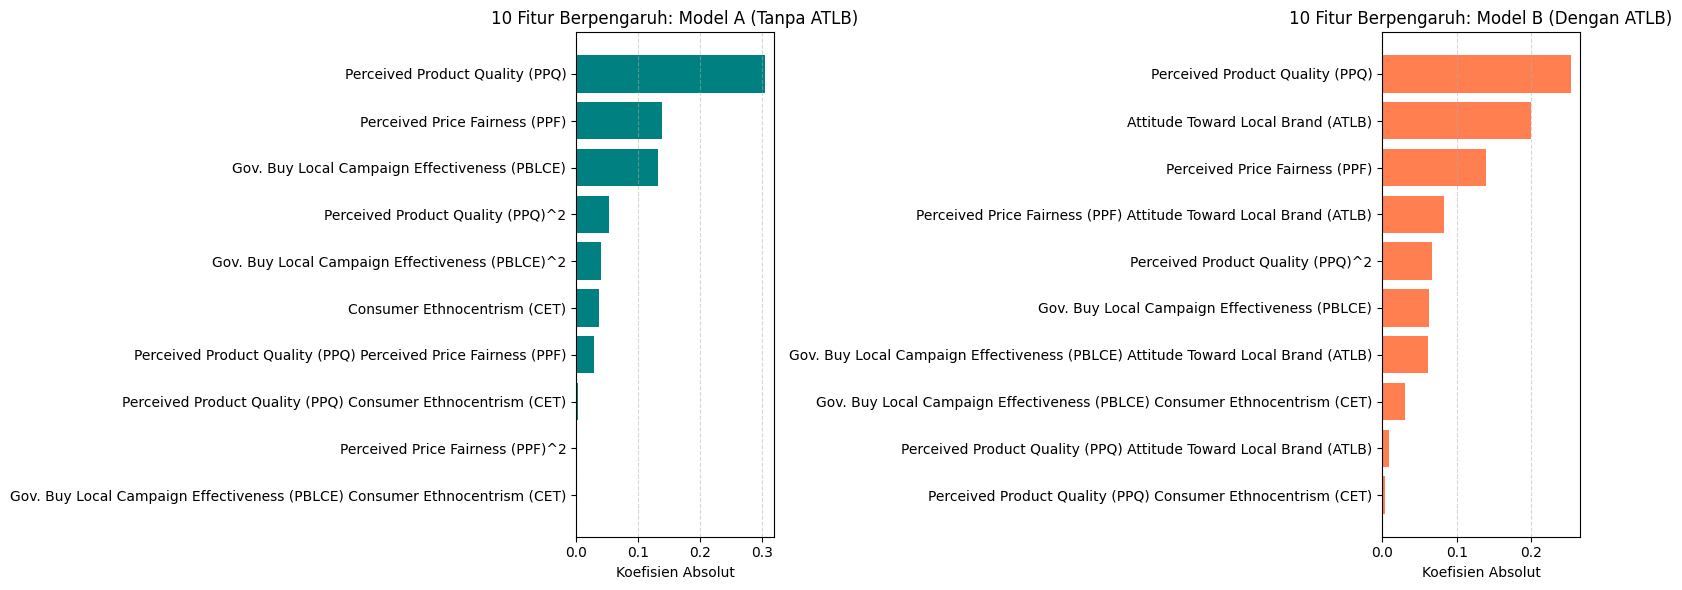

In [ ]:
en_model_a = model_en_a.named_steps['elasticnet']
en_model_b = model_en_b.named_steps['elasticnet']

# Membuat DataFrame untuk perbandingan koefisien (menggunakan poly_cols)
importance_a = pd.DataFrame({'Feature': poly_cols_a, 'Importance': np.abs(en_model_a.coef_)})
importance_b = pd.DataFrame({'Feature': poly_cols_b, 'Importance': np.abs(en_model_b.coef_)})

# PERBAIKAN: Membatasi ke 10 fitur terpenting agar grafik tidak berantakan
top_10_a = importance_a.sort_values(by='Importance', ascending=True).tail(10)
top_10_b = importance_b.sort_values(by='Importance', ascending=True).tail(10)

# Visualisasi Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Model A
axes[0].barh(top_10_a['Feature'], top_10_a['Importance'], color='teal')
axes[0].set_title('10 Fitur Berpengaruh: Model A (Tanpa ATLB)')
axes[0].set_xlabel('Koefisien Absolut')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Plot Model B
axes[1].barh(top_10_b['Feature'], top_10_b['Importance'], color='coral')
axes[1].set_title('10 Fitur Berpengaruh: Model B (Dengan ATLB)')
axes[1].set_xlabel('Koefisien Absolut')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


--- Sampel Prediksi Elastic Net Model A (Tanpa Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407 -0.117601 -0.590857         0.473256
444 -0.299373  0.479230        -0.778604
117 -0.117601  0.032122        -0.149724
30   0.393104  0.525099        -0.131995
415  1.530275  0.877397         0.652878
157 -1.190307  0.501191        -1.691499
325  0.942427  0.446563         0.495864
447  0.012334  0.448470        -0.436136
268  0.406043 -1.092979         1.499022
297  0.176265  0.668385        -0.492120


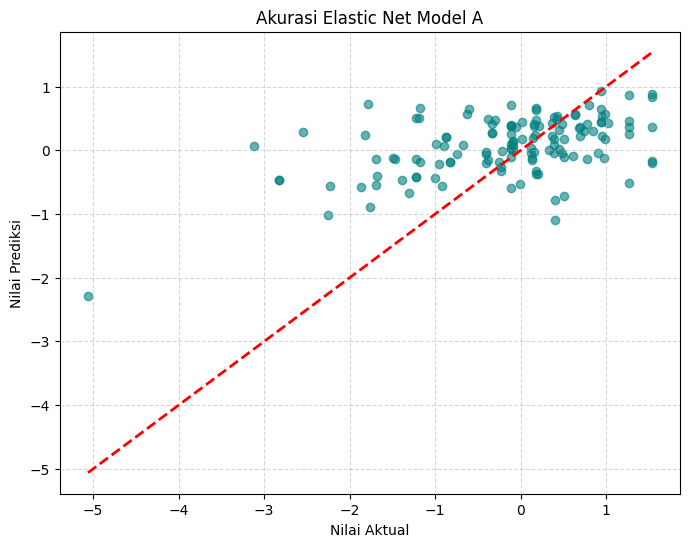

In [ ]:
hasil_prediksi_en_a = pd.DataFrame({
    'Aktual': y_test_a,
    'Prediksi': y_pred_a,
    'Selisih (Error)': y_test_a - y_pred_a
})
print("\n--- Sampel Prediksi Elastic Net Model A (Tanpa Mediator ATLB) ---")
print(hasil_prediksi_en_a.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_en_a['Aktual'], hasil_prediksi_en_a['Prediksi'], alpha=0.6, color='teal')
plt.plot([hasil_prediksi_en_a['Aktual'].min(), hasil_prediksi_en_a['Aktual'].max()],
         [hasil_prediksi_en_a['Aktual'].min(), hasil_prediksi_en_a['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi Elastic Net Model A')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


--- Sampel Prediksi Elastic Net Model B (Dengan Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407 -0.117601 -0.434428         0.316827
444 -0.299373  0.436220        -0.735593
117 -0.117601 -0.140485         0.022884
30   0.393104  0.490214        -0.097110
415  1.530275  0.812592         0.717683
157 -1.190307  0.620165        -1.810473
325  0.942427  0.517747         0.424680
447  0.012334  0.523642        -0.511308
268  0.406043 -1.401416         1.807459
297  0.176265  0.652675        -0.476411


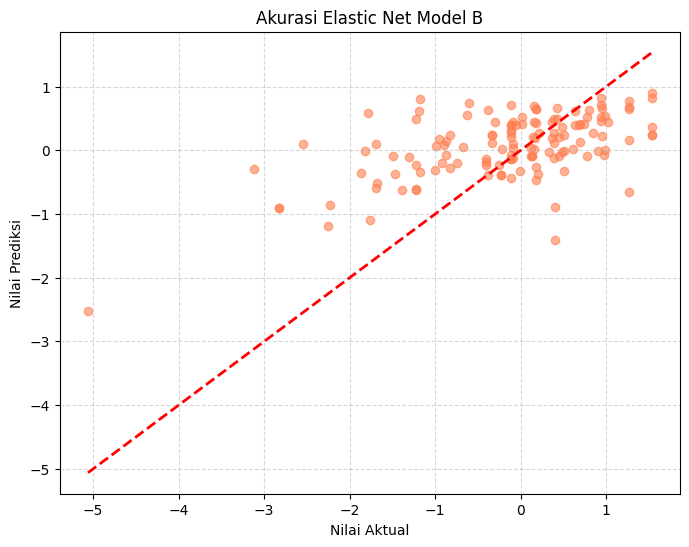

In [ ]:
hasil_prediksi_en_b = pd.DataFrame({
    'Aktual': y_test_b,
    'Prediksi': y_pred_b,
    'Selisih (Error)': y_test_b - y_pred_b
})
print("\n--- Sampel Prediksi Elastic Net Model B (Dengan Mediator ATLB) ---")
print(hasil_prediksi_en_b.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_en_b['Aktual'], hasil_prediksi_en_b['Prediksi'], alpha=0.6, color='coral')
plt.plot([hasil_prediksi_en_b['Aktual'].min(), hasil_prediksi_en_b['Aktual'].max()],
         [hasil_prediksi_en_b['Aktual'].min(), hasil_prediksi_en_b['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi Elastic Net Model B')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## XGBOOST (GEN Y)

In [ ]:
def process_xgboost(features, target_col, df, model_name):
    X = df[features]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # XGBoost tidak memerlukan Standard Scaler
    model = XGBRegressor(random_state=42, objective='reg:squarederror')

    # Grid Search untuk hyperparameter XGBoost
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }

    grid = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    results = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }
    return results, best_model, X_test, y_test, y_pred

In [ ]:
res_xgb_a, model_xgb_a, X_test_xgb_a, y_test_xgb_a, y_pred_xgb_a = process_xgboost(poly_cols_a, target, df_model_a, "XGBoost - Model A (Poly)")
res_xgb_b, model_xgb_b, X_test_xgb_b, y_test_xgb_b, y_pred_xgb_b = process_xgboost(poly_cols_b, target, df_model_b, "XGBoost - Model B (Poly)")

df_results_xgb = pd.DataFrame([res_xgb_a, res_xgb_b])
print("\n--- Perbandingan Performa XGBoost ---")
print(df_results_xgb)


--- Perbandingan Performa XGBoost ---
                      Model      RMSE       MAE        R2
0  XGBoost - Model A (Poly)  1.013846  0.743682  0.101126
1  XGBoost - Model B (Poly)  0.938842  0.700758  0.229203


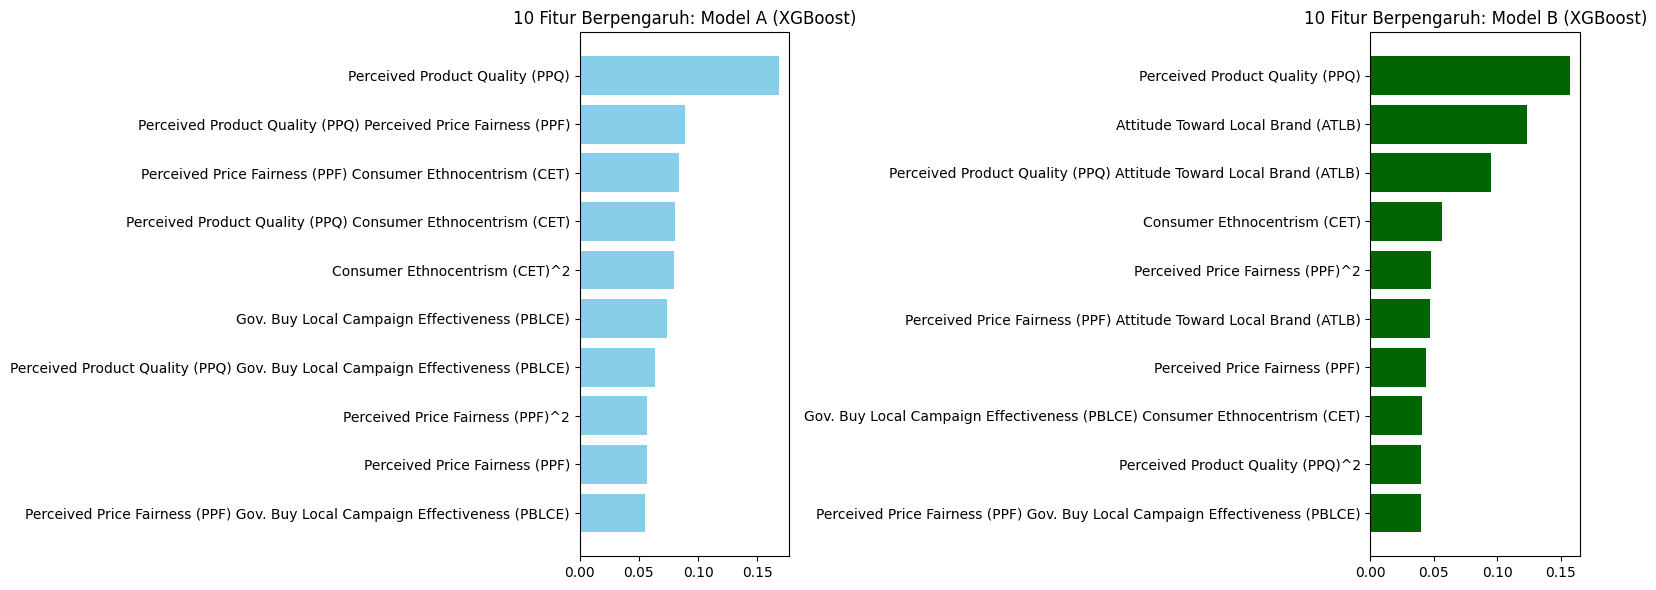

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (model, feat, title, color) in enumerate([(model_xgb_a, poly_cols_a, 'Model A', 'skyblue'),
                                                 (model_xgb_b, poly_cols_b, 'Model B', 'darkgreen')]):
    importance = pd.DataFrame({'Feature': feat, 'Importance': model.feature_importances_})

    # Menambahkan .tail(10) agar hanya menampilkan 10 fitur terpenting
    importance = importance.sort_values('Importance', ascending=True).tail(10)

    axes[i].barh(importance['Feature'], importance['Importance'], color=color)
    axes[i].set_title(f'10 Fitur Berpengaruh: {title} (XGBoost)')

plt.tight_layout()
plt.show()


--- Sampel Prediksi XGBoost Model A (Tanpa Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407 -0.117601 -0.554649         0.437048
444 -0.299373  0.475894        -0.775267
117 -0.117601  0.482065        -0.599666
30   0.393104  0.497146        -0.104042
415  1.530275  0.990955         0.539320
157 -1.190307  0.516920        -1.707227
325  0.942427  0.510355         0.432072
447  0.012334  0.474974        -0.462640
268  0.406043 -0.155846         0.561889
297  0.176265  0.670316        -0.494051


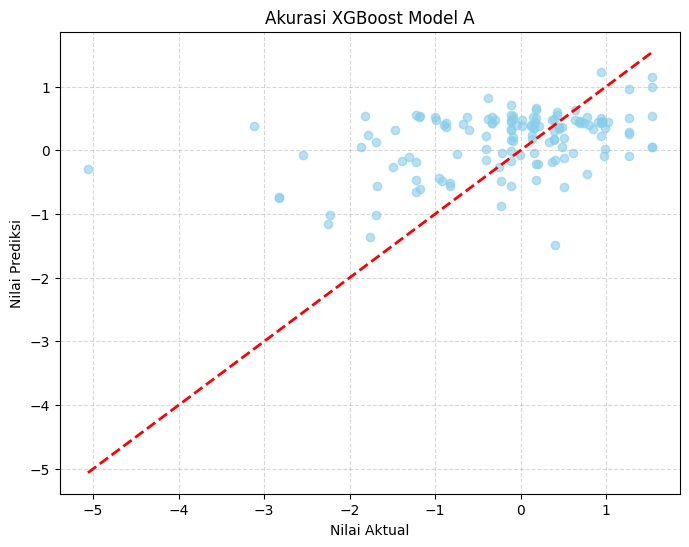

In [ ]:
hasil_prediksi_xgb_a = pd.DataFrame({
    'Aktual': y_test_xgb_a,
    'Prediksi': y_pred_xgb_a,
    'Selisih (Error)': y_test_xgb_a - y_pred_xgb_a
})
print("\n--- Sampel Prediksi XGBoost Model A (Tanpa Mediator ATLB) ---")
print(hasil_prediksi_xgb_a.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_xgb_a['Aktual'], hasil_prediksi_xgb_a['Prediksi'], alpha=0.6, color='skyblue')
plt.plot([hasil_prediksi_xgb_a['Aktual'].min(), hasil_prediksi_xgb_a['Aktual'].max()],
         [hasil_prediksi_xgb_a['Aktual'].min(), hasil_prediksi_xgb_a['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi XGBoost Model A')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


--- Sampel Prediksi XGBoost Model B (Dengan Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407 -0.117601 -0.075766        -0.041836
444 -0.299373  0.505534        -0.804907
117 -0.117601  0.287768        -0.405370
30   0.393104  0.505534        -0.112430
415  1.530275  0.946487         0.583788
157 -1.190307  0.584864        -1.775171
325  0.942427  0.604931         0.337496
447  0.012334  0.535982        -0.523648
268  0.406043 -0.959928         1.365971
297  0.176265  0.627118        -0.450853


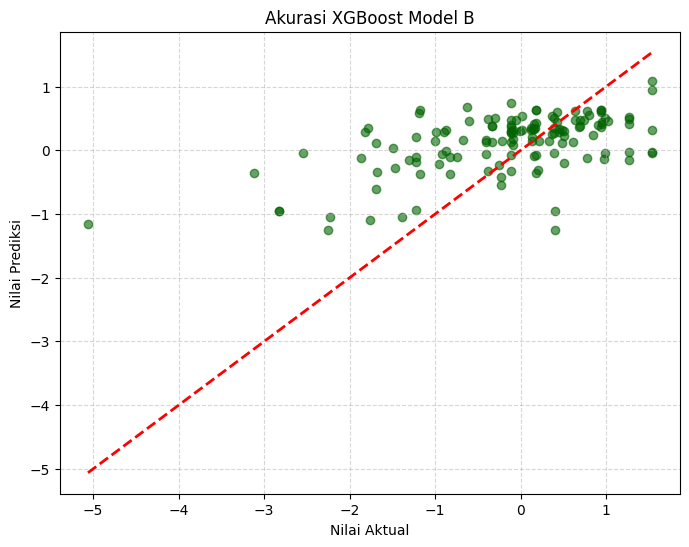

In [ ]:
hasil_prediksi_xgb_b = pd.DataFrame({
    'Aktual': y_test_xgb_b,
    'Prediksi': y_pred_xgb_b,
    'Selisih (Error)': y_test_xgb_b - y_pred_xgb_b
})
print("\n--- Sampel Prediksi XGBoost Model B (Dengan Mediator ATLB) ---")
print(hasil_prediksi_xgb_b.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_xgb_b['Aktual'], hasil_prediksi_xgb_b['Prediksi'], alpha=0.6, color='darkgreen')
plt.plot([hasil_prediksi_xgb_b['Aktual'].min(), hasil_prediksi_xgb_b['Aktual'].max()],
         [hasil_prediksi_xgb_b['Aktual'].min(), hasil_prediksi_xgb_b['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi XGBoost Model B')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## GAUSSIAN PROGRESS REGRESSOR (GEN Y)

In [ ]:
def process_gpr_model(features, target_col, df, model_name):
    X = df[features]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # GPR sangat sensitif terhadap skala
    kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
    model = make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(kernel=kernel, random_state=42, n_restarts_optimizer=5)
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE' : mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }
    return results, model, X_test, y_test, y_pred

In [ ]:
res_gpr_a, model_gpr_a, X_test_a, y_test_a, y_pred_a = process_gpr_model(poly_cols_a, target, df_model_a, "GPR Model A")
res_gpr_b, model_gpr_b, X_test_b, y_test_b, y_pred_b = process_gpr_model(poly_cols_b, target, df_model_b, "GPR Model B")

# Menampilkan Hasil Performa
df_gpr_results = pd.DataFrame([res_gpr_a, res_gpr_b])
print("\n--- Perbandingan Performa GPR ---")
print(df_gpr_results)


--- Perbandingan Performa GPR ---
         Model      RMSE       MAE        R2
0  GPR Model A  1.037485  0.742014  0.058721
1  GPR Model B  0.994312  0.716470  0.135431



Menghitung Permutation Importance untuk GPR (mohon tunggu sebentar)...


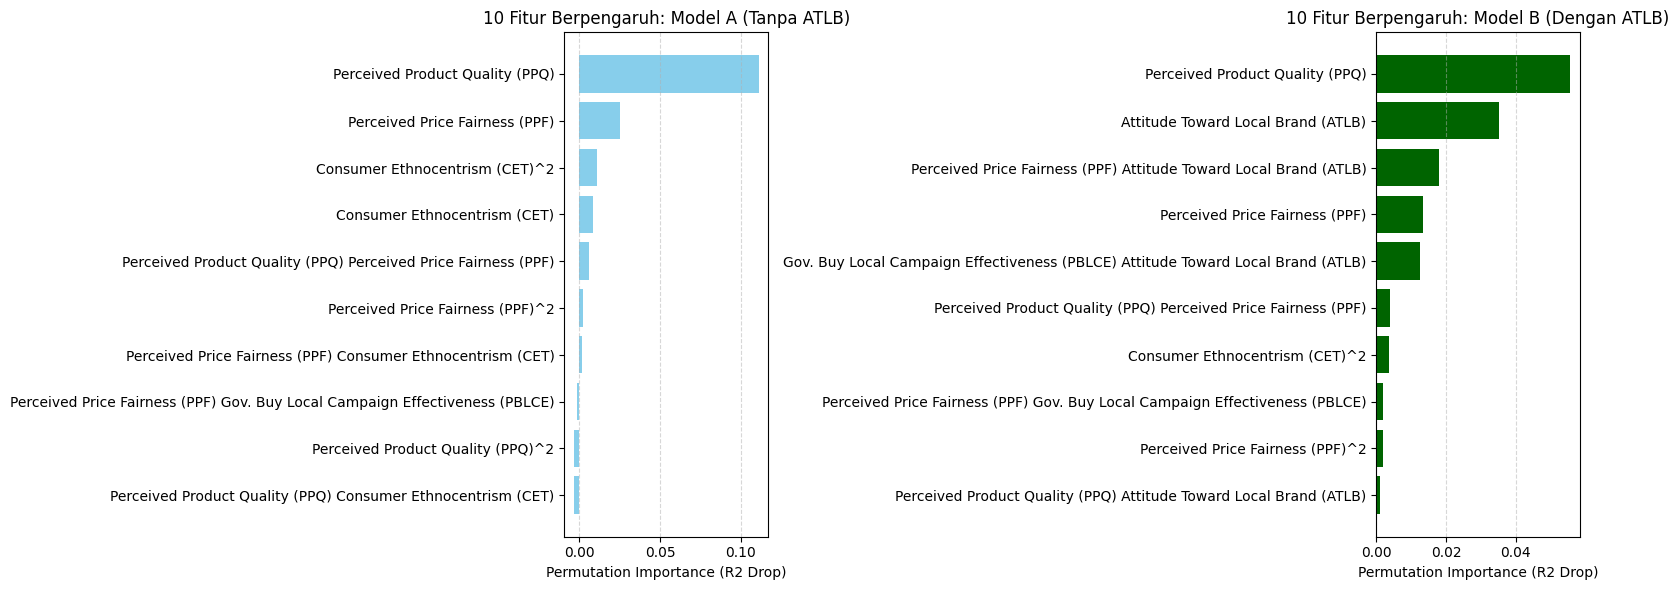

In [ ]:
print("\nMenghitung Permutation Importance untuk GPR (mohon tunggu sebentar)...")
perm_a = permutation_importance(model_gpr_a, X_test_a, y_test_a, n_repeats=10, random_state=42, scoring='r2')
importance_a = pd.DataFrame({'Feature': poly_cols_a, 'Importance': perm_a.importances_mean})

perm_b = permutation_importance(model_gpr_b, X_test_b, y_test_b, n_repeats=10, random_state=42, scoring='r2')
importance_b = pd.DataFrame({'Feature': poly_cols_b, 'Importance': perm_b.importances_mean})

# Mengurutkan dan mengambil 10 besar saja agar grafik terbaca
top_10_a = importance_a.sort_values(by='Importance', ascending=True).tail(10)
top_10_b = importance_b.sort_values(by='Importance', ascending=True).tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Model A
axes[0].barh(top_10_a['Feature'], top_10_a['Importance'], color='skyblue')
axes[0].set_title('10 Fitur Berpengaruh: Model A (Tanpa ATLB)')
axes[0].set_xlabel('Permutation Importance (R2 Drop)')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Plot Model B
axes[1].barh(top_10_b['Feature'], top_10_b['Importance'], color='darkgreen')
axes[1].set_title('10 Fitur Berpengaruh: Model B (Dengan ATLB)')
axes[1].set_xlabel('Permutation Importance (R2 Drop)')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


--- Sampel Prediksi GPR Model A (Tanpa Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407 -0.117601 -1.008703         0.891101
444 -0.299373  0.611561        -0.910934
117 -0.117601  0.413491        -0.531093
30   0.393104  0.483796        -0.090692
415  1.530275  1.105719         0.424556
157 -1.190307  0.650410        -1.840718
325  0.942427  0.645814         0.296613
447  0.012334  0.561185        -0.548850
268  0.406043 -0.005248         0.411291
297  0.176265  0.509727        -0.333462


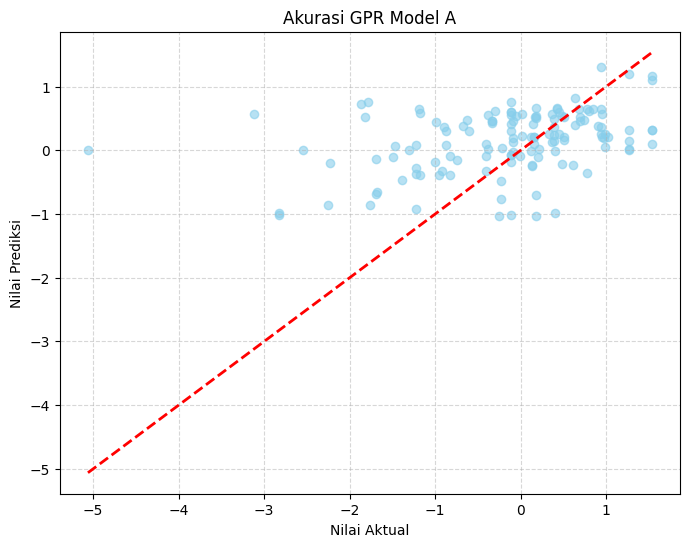

In [ ]:
hasil_prediksi_gpr_a = pd.DataFrame({
    'Aktual': y_test_a,
    'Prediksi': y_pred_a,
    'Selisih (Error)': y_test_a - y_pred_a
})
print("\n--- Sampel Prediksi GPR Model A (Tanpa Mediator ATLB) ---")
print(hasil_prediksi_gpr_a.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_gpr_a['Aktual'], hasil_prediksi_gpr_a['Prediksi'], alpha=0.6, color='skyblue')
plt.plot([hasil_prediksi_gpr_a['Aktual'].min(), hasil_prediksi_gpr_a['Aktual'].max()],
         [hasil_prediksi_gpr_a['Aktual'].min(), hasil_prediksi_gpr_a['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi GPR Model A')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


--- 10 Sampel Prediksi GPR Model B (Dengan Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407 -0.117601 -0.643886         0.526284
444 -0.299373  0.586262        -0.885635
117 -0.117601  0.132461        -0.250063
30   0.393104  0.494587        -0.101482
415  1.530275  1.062030         0.468244
157 -1.190307  0.787026        -1.977333
325  0.942427  0.650911         0.291516
447  0.012334  0.659112        -0.646778
268  0.406043  0.053330         0.352714
297  0.176265  0.541917        -0.365652


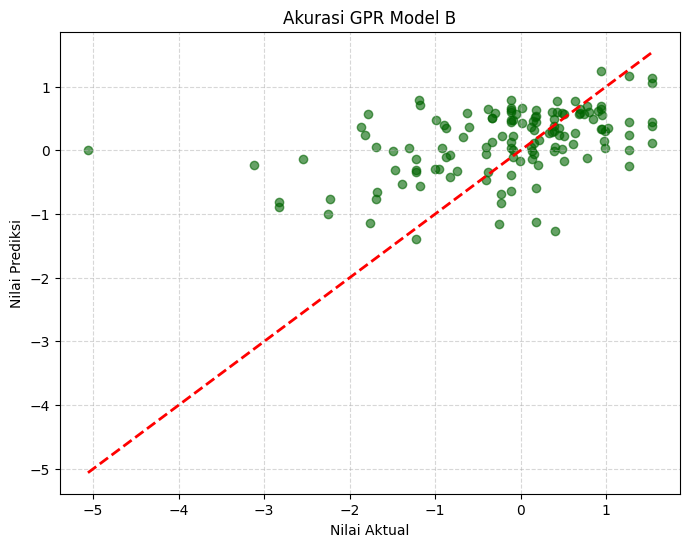

In [ ]:
hasil_prediksi_gpr_b = pd.DataFrame({
    'Aktual': y_test_b,
    'Prediksi': y_pred_b,
    'Selisih (Error)': y_test_b - y_pred_b
})

print("\n--- 10 Sampel Prediksi GPR Model B (Dengan Mediator ATLB) ---")
print(hasil_prediksi_gpr_b.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_gpr_b['Aktual'], hasil_prediksi_gpr_b['Prediksi'], alpha=0.6, color='darkgreen')
plt.plot([hasil_prediksi_gpr_b['Aktual'].min(), hasil_prediksi_gpr_b['Aktual'].max()],
         [hasil_prediksi_gpr_b['Aktual'].min(), hasil_prediksi_gpr_b['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi GPR Model B')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 450 (GEN Z)

## IMPORT (GEN Z)

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import requests
import io
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.preprocessing import PolynomialFeatures

## PRE PROCESSING (GEN Z)

In [2]:
urlx = "https://raw.githubusercontent.com/hqq24/project/refs/heads/main/data%20gen%20z%20(1).csv"
response = requests.get(urlx)
content = response.content.decode('utf-8')

# Gunakan StringIO untuk membaca file dan skip baris yang tidak perlu
dfx = pd.read_csv(io.StringIO(content), skiprows=5)

# Bersihkan nama kolom
dfx.columns = dfx.columns.str.strip()

# Hapus kolom yang tidak bernama
dfx = dfx.loc[:, ~dfx.columns.str.contains('^Unnamed')]

# Hapus baris kosong
dfx = dfx.dropna(how='all')

print(f"Jumlah baris data: {dfx.shape[0]}")
print("\nPreview Data:")
print(dfx.head())

Jumlah baris data: 450

Preview Data:
   Case ID  Attitude Toward Local Brand (ATLB)  Consumer Ethnocentrism (CET)  \
0      451                            0.729516                      0.777559   
1      452                            0.149294                      0.541580   
2      453                            0.741772                      0.130107   
3      454                            0.967892                      0.502914   
4      455                            0.729516                      0.837590   

   Gov. Buy Local Campaign Effectiveness (PBLCE)  \
0                                      -1.667755   
1                                       0.483202   
2                                      -0.151489   
3                                       1.364777   
4                                      -0.151489   

   Local Fashion Brand Love (LFBL)  Perceived Price Fairness (PPF)  \
0                         0.714782                       -1.434859   
1                         0.

In [3]:
# pembagian Model A
features_a = ['Perceived Product Quality (PPQ)',
              'Perceived Price Fairness (PPF)',
              'Gov. Buy Local Campaign Effectiveness (PBLCE)',
              'Consumer Ethnocentrism (CET)']

# pembagian Model B
features_b = features_a + ['Attitude Toward Local Brand (ATLB)']

# variabel target
target = 'Local Fashion Brand Love (LFBL)'

In [4]:
poly_a = PolynomialFeatures(degree=2, include_bias=False)
X_poly_a = poly_a.fit_transform(dfx[features_a])
# PERBAIKAN: Menggunakan get_feature_names_out agar nama fitur aslinya terbawa
poly_cols_a = poly_a.get_feature_names_out(features_a)
df_poly_a = pd.DataFrame(X_poly_a, columns=poly_cols_a, index=dfx.index)

# Polynomial Features Model B
poly_b = PolynomialFeatures(degree=2, include_bias=False)
X_poly_b = poly_b.fit_transform(dfx[features_b])
# PERBAIKAN: Sama untuk Model B
poly_cols_b = poly_b.get_feature_names_out(features_b)
df_poly_b = pd.DataFrame(X_poly_b, columns=poly_cols_b, index=dfx.index)

# Menggabungkan fitur polynomial ke dataframe asli
df_model_a = df_poly_a.copy()
df_model_a[target] = dfx[target] # Hanya memasukkan kolom 'Local Fashion Brand Love (LFBL)'

df_model_b = df_poly_b.copy()
df_model_b[target] = dfx[target]

## RANDOM FOREST (GEN Z)

In [ ]:
def process_rf_model_engineered(features_list, target_col, df_source, model_name):
    # Menggunakan kolom hasil feature engineering
    X = df_source[features_list]
    y = df_source[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    param_grid = {
        'n_estimators': [300, 500],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    }

    grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)

    print(f"Sedang melatih {model_name} dengan Polynomial Features...")
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    results = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

    return results, best_model, X_test, y_test, y_pred

In [ ]:
try:
    print("\n--- Memulai Proses Modeling ---")
    res_a, model_a, X_test_a, y_test_a, y_pred_a = process_rf_model_engineered(
        poly_cols_a, target, df_model_a, "Model A (Polynomial)"
    )
    res_b, model_b, X_test_b, y_test_b, y_pred_b = process_rf_model_engineered(
        poly_cols_b, target, df_model_b, "Model B (Polynomial)"
    )

    df_results = pd.DataFrame([res_a, res_b])

    print("\n--- Perbandingan Performa Akhir ---")
    print(df_results)

except Exception as e:
    print(f"\nTerjadi Kesalahan saat melatih model: {e}")



--- Memulai Proses Modeling ---
Sedang melatih Model A (Polynomial) dengan Polynomial Features...
Sedang melatih Model B (Polynomial) dengan Polynomial Features...

--- Perbandingan Performa Akhir ---
                  Model      RMSE       MAE        R2
0  Model A (Polynomial)  0.451920  0.356486  0.758808
1  Model B (Polynomial)  0.448047  0.334131  0.762925



--- Membuat Visualisasi Permutation Importance ---


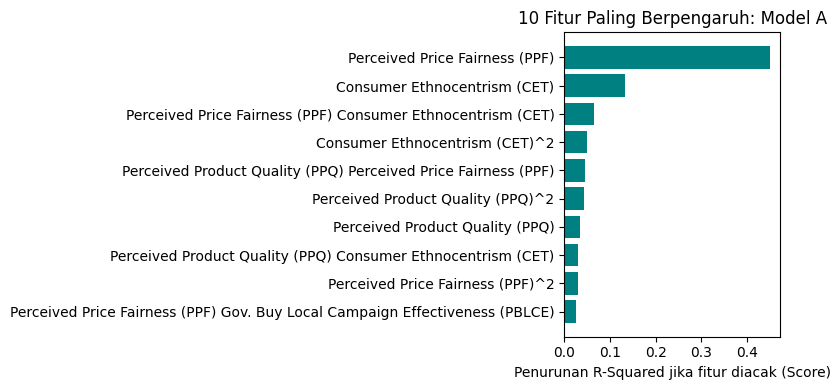

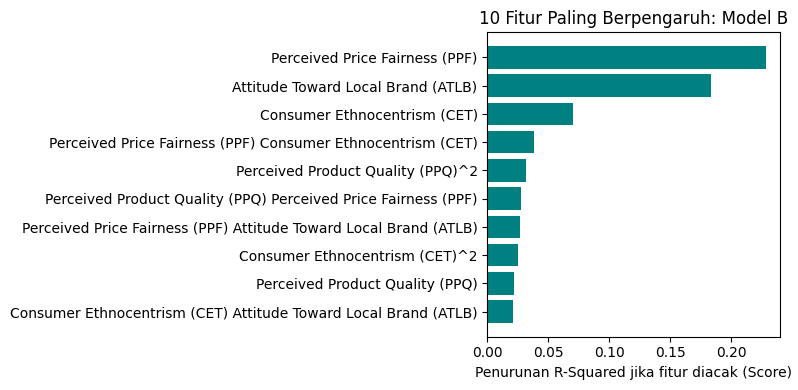

In [ ]:
def plot_importance(model, features, X_test, y_test, name):
    perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='r2')

    importance_df = pd.DataFrame({'Feature': features, 'Importance': perm_importance.importances_mean})
    importance_df = importance_df.sort_values(by='Importance', ascending=True)

    # Menampilkan hanya 10 fitur terpenting
    importance_df = importance_df.tail(10)

    plt.figure(figsize=(8, 4))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
    plt.title(f'10 Fitur Paling Berpengaruh: {name}')
    plt.xlabel('Penurunan R-Squared jika fitur diacak (Score)')
    plt.tight_layout()
    plt.show()

print("\n--- Membuat Visualisasi Permutation Importance ---")
plot_importance(model_a, poly_cols_a, X_test_a, y_test_a, "Model A")
plot_importance(model_b, poly_cols_b, X_test_b, y_test_b, "Model B")


--- 10 Sampel Prediksi Model A (Tanpa Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407  1.335353  1.182401         0.152951
444  0.714806  0.394571         0.320235
117 -1.880795 -0.902307        -0.978488
30   0.768776  0.342289         0.426487
415 -0.415412 -0.814954         0.399542
157  1.065767  0.557374         0.508393
325  0.431731 -0.087945         0.519676
447  0.488008  0.489663        -0.001655
268 -1.880795 -1.366755        -0.514040
297  0.995550  0.380057         0.615493


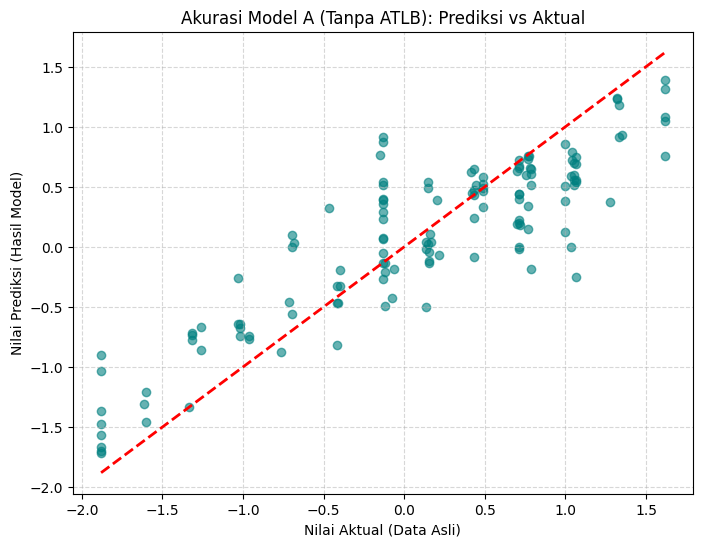

In [ ]:
hasil_prediksi_a = pd.DataFrame({
    'Aktual': y_test_a,
    'Prediksi': y_pred_a,
    'Selisih (Error)': y_test_a - y_pred_a
})

print("\n--- 10 Sampel Prediksi Model A (Tanpa Mediator ATLB) ---")
print(hasil_prediksi_a.head(10))

# Scatter Plot Model A
plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_a['Aktual'], hasil_prediksi_a['Prediksi'], alpha=0.6, color='teal')
plt.plot([hasil_prediksi_a['Aktual'].min(), hasil_prediksi_a['Aktual'].max()],
         [hasil_prediksi_a['Aktual'].min(), hasil_prediksi_a['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual (Data Asli)')
plt.ylabel('Nilai Prediksi (Hasil Model)')
plt.title('Akurasi Model A (Tanpa ATLB): Prediksi vs Aktual')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


--- 10 Sampel Prediksi Model B (Dengan Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407  1.335353  1.226215         0.109138
444  0.714806  0.628279         0.086527
117 -1.880795 -0.603658        -1.277137
30   0.768776  0.677679         0.091097
415 -0.415412 -0.742623         0.327211
157  1.065767  0.748508         0.317259
325  0.431731 -0.050139         0.481870
447  0.488008  0.524142        -0.036134
268 -1.880795 -1.327505        -0.553290
297  0.995550  0.155290         0.840260


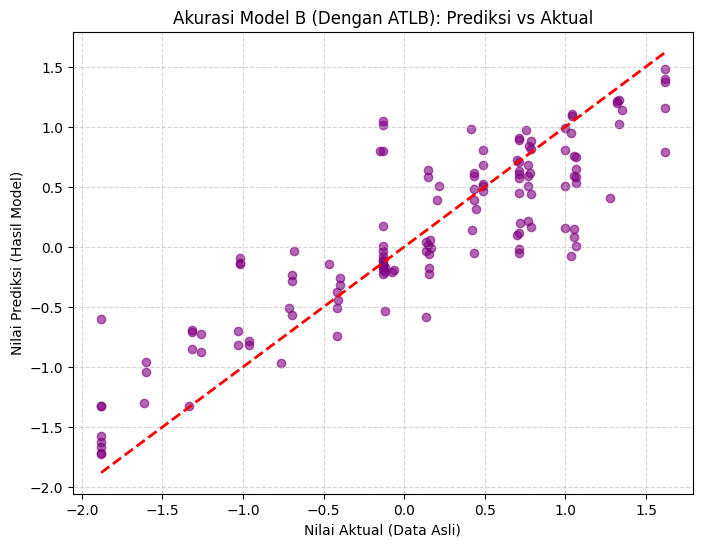

In [ ]:
hasil_prediksi_b = pd.DataFrame({
    'Aktual': y_test_b,
    'Prediksi': y_pred_b,
    'Selisih (Error)': y_test_b - y_pred_b
})

print("\n--- 10 Sampel Prediksi Model B (Dengan Mediator ATLB) ---")
print(hasil_prediksi_b.head(10))

# Scatter Plot Model B
plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_b['Aktual'], hasil_prediksi_b['Prediksi'], alpha=0.6, color='purple')
plt.plot([hasil_prediksi_b['Aktual'].min(), hasil_prediksi_b['Aktual'].max()],
         [hasil_prediksi_b['Aktual'].min(), hasil_prediksi_b['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual (Data Asli)')
plt.ylabel('Nilai Prediksi (Hasil Model)')
plt.title('Akurasi Model B (Dengan ATLB): Prediksi vs Aktual')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## BAYESIAN RIDGE REGRESSION (GEN Z)

In [ ]:
def process_bayesian_model(features, target_col, df, model_name):
    X = df[features]
    y = df[target_col]

    # Split 70% Train, 30% Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Bayesian Ridge menggunakan StandardScaler di dalam Pipeline
    model = make_pipeline(
        StandardScaler(),
        BayesianRidge()
    )

    print(f"Sedang melatih {model_name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE' : mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

    return results, model, X_test, y_test, y_pred

In [ ]:
print("\n--- Memulai Proses Modeling Bayesian Ridge ---")
res_br_a, model_br_a, X_test_a, y_test_a, y_pred_a = process_bayesian_model(poly_cols_a, target, df_model_a, "Bayesian Model A")
res_br_b, model_br_b, X_test_b, y_test_b, y_pred_b = process_bayesian_model(poly_cols_b, target, df_model_b, "Bayesian Model B")

df_br_results = pd.DataFrame([res_br_a, res_br_b])
print("\n--- Perbandingan Performa Bayesian Ridge ---")
print(df_br_results)


--- Memulai Proses Modeling Bayesian Ridge ---
Sedang melatih Bayesian Model A...
Sedang melatih Bayesian Model B...

--- Perbandingan Performa Bayesian Ridge ---
              Model      RMSE       MAE        R2
0  Bayesian Model A  0.603497  0.490609  0.569880
1  Bayesian Model B  0.599133  0.463348  0.576078



--- Membuat Visualisasi Feature Importance (Koefisien) ---


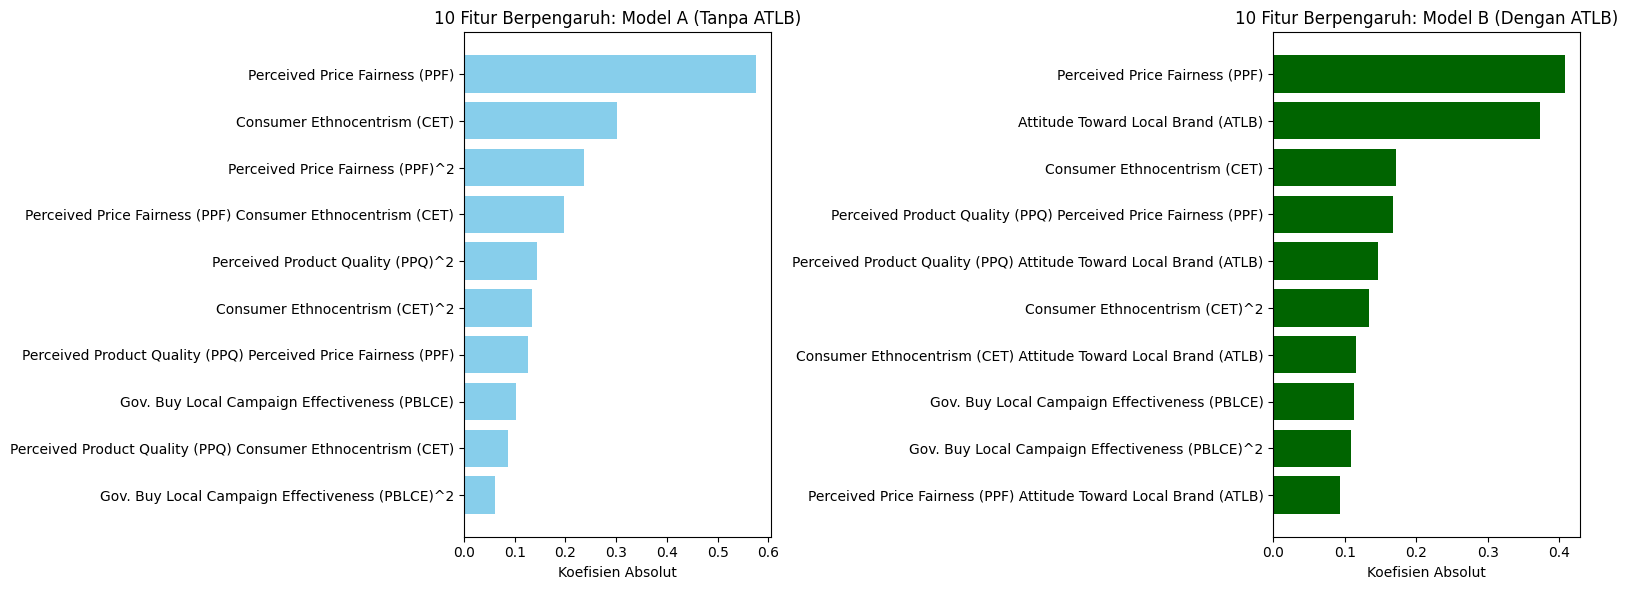

In [ ]:
print("\n--- Membuat Visualisasi Feature Importance (Koefisien) ---")
# Mengambil model BayesianRidge dari dalam Pipeline
br_model_a = model_br_a.named_steps['bayesianridge']
br_model_b = model_br_b.named_steps['bayesianridge']

# Membuat DataFrame untuk perbandingan koefisien absolut
importance_a = pd.DataFrame({'Feature': poly_cols_a, 'Importance': np.abs(br_model_a.coef_)})
importance_b = pd.DataFrame({'Feature': poly_cols_b, 'Importance': np.abs(br_model_b.coef_)})

# Mengurutkan dan mengambil 10 besar saja agar grafik terbaca
top_10_a = importance_a.sort_values(by='Importance', ascending=True).tail(10)
top_10_b = importance_b.sort_values(by='Importance', ascending=True).tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Model A
axes[0].barh(top_10_a['Feature'], top_10_a['Importance'], color='skyblue')
axes[0].set_title('10 Fitur Berpengaruh: Model A (Tanpa ATLB)')
axes[0].set_xlabel('Koefisien Absolut')

# Plot Model B
axes[1].barh(top_10_b['Feature'], top_10_b['Importance'], color='darkgreen')
axes[1].set_title('10 Fitur Berpengaruh: Model B (Dengan ATLB)')
axes[1].set_xlabel('Koefisien Absolut')

plt.tight_layout()
plt.show()


--- Sampel Prediksi Bayesian Model A (Tanpa Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407  1.335353  0.840807         0.494545
444  0.714806  0.546922         0.167884
117 -1.880795 -1.358811        -0.521984
30   0.768776 -0.032756         0.801532
415 -0.415412 -1.126611         0.711199
157  1.065767  0.799469         0.266298
325  0.431731 -0.157739         0.589469
447  0.488008  0.751087        -0.263079
268 -1.880795 -1.521616        -0.359179
297  0.995550  0.575017         0.420533


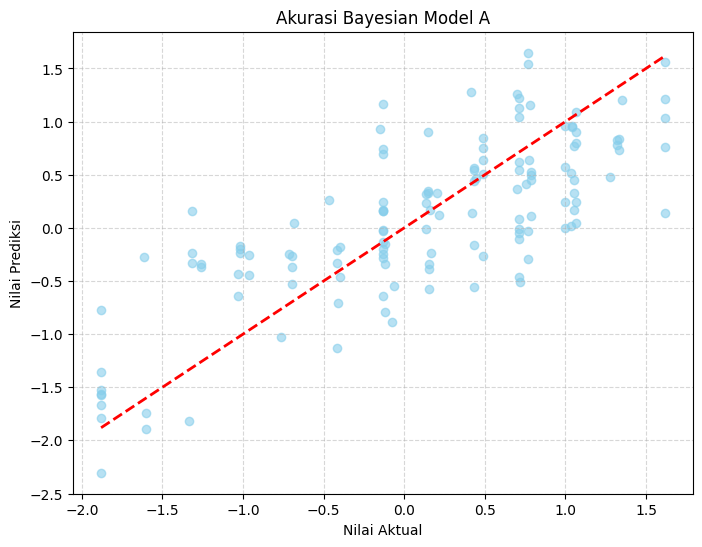

In [ ]:
hasil_prediksi_br_a = pd.DataFrame({
    'Aktual': y_test_a,
    'Prediksi': y_pred_a,
    'Selisih (Error)': y_test_a - y_pred_a
})
print("\n--- Sampel Prediksi Bayesian Model A (Tanpa Mediator ATLB) ---")
print(hasil_prediksi_br_a.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_br_a['Aktual'], hasil_prediksi_br_a['Prediksi'], alpha=0.6, color='skyblue')
plt.plot([hasil_prediksi_br_a['Aktual'].min(), hasil_prediksi_br_a['Aktual'].max()],
         [hasil_prediksi_br_a['Aktual'].min(), hasil_prediksi_br_a['Aktual'].max()], 'r--', lw=2)

plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi Bayesian Model A')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


--- Sampel Prediksi Bayesian Model B (Dengan Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407  1.335353  0.946581         0.388772
444  0.714806  0.629619         0.085187
117 -1.880795 -0.433102        -1.447693
30   0.768776  0.362026         0.406750
415 -0.415412 -1.204614         0.789202
157  1.065767  0.826936         0.238831
325  0.431731 -0.197526         0.629257
447  0.488008  0.717843        -0.229835
268 -1.880795 -1.293316        -0.587479
297  0.995550  0.290385         0.705165


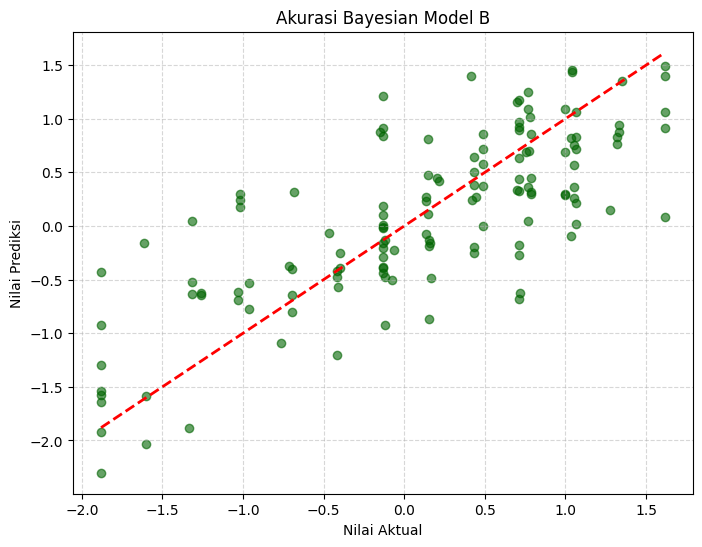

In [ ]:
hasil_prediksi_br_b = pd.DataFrame({
    'Aktual': y_test_b,
    'Prediksi': y_pred_b,
    'Selisih (Error)': y_test_b - y_pred_b
})
print("\n--- Sampel Prediksi Bayesian Model B (Dengan Mediator ATLB) ---")
print(hasil_prediksi_br_b.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_br_b['Aktual'], hasil_prediksi_br_b['Prediksi'], alpha=0.6, color='darkgreen')
plt.plot([hasil_prediksi_br_b['Aktual'].min(), hasil_prediksi_br_b['Aktual'].max()],
         [hasil_prediksi_br_b['Aktual'].min(), hasil_prediksi_br_b['Aktual'].max()], 'r--', lw=2)

plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Akurasi Bayesian Model B')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## ELASTIC NET REGRESSION (GEN Z)

In [5]:
def process_elastic_net(features, target_col, df, model_name):
    X = df[features]
    y = df[target_col]

    # Split data 70:30
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Pipeline: Standarisasi + Model
    pipeline = make_pipeline(StandardScaler(), ElasticNet(random_state=42))

    # Grid Search untuk mencari kombinasi parameter terbaik
    param_grid = {
        'elasticnet__alpha': [0.001, 0.01, 0.1, 1, 10],
        'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    }

    # cv=5 dan n_jobs=-1 agar eksekusi lebih cepat
    grid = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    # Simpan hasil metrik
    results = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

    return results, best_model, X_test, y_test, y_pred

In [6]:
res_en_a, model_en_a, X_test_a, y_test_a, y_pred_a = process_elastic_net(poly_cols_a, target, df_model_a, "Model A (Elastic Net)")
res_en_b, model_en_b, X_test_b, y_test_b, y_pred_b = process_elastic_net(poly_cols_b, target, df_model_b, "Model B (Elastic Net)")

# Perbandingan performa metrik
df_results = pd.DataFrame([res_en_a, res_en_b])
print("\n--- Perbandingan Performa Elastic Net ---")
print(df_results)


--- Perbandingan Performa Elastic Net ---
                   Model      RMSE       MAE        R2
0  Model A (Elastic Net)  0.644744  0.506289  0.509076
1  Model B (Elastic Net)  0.624444  0.476826  0.539504


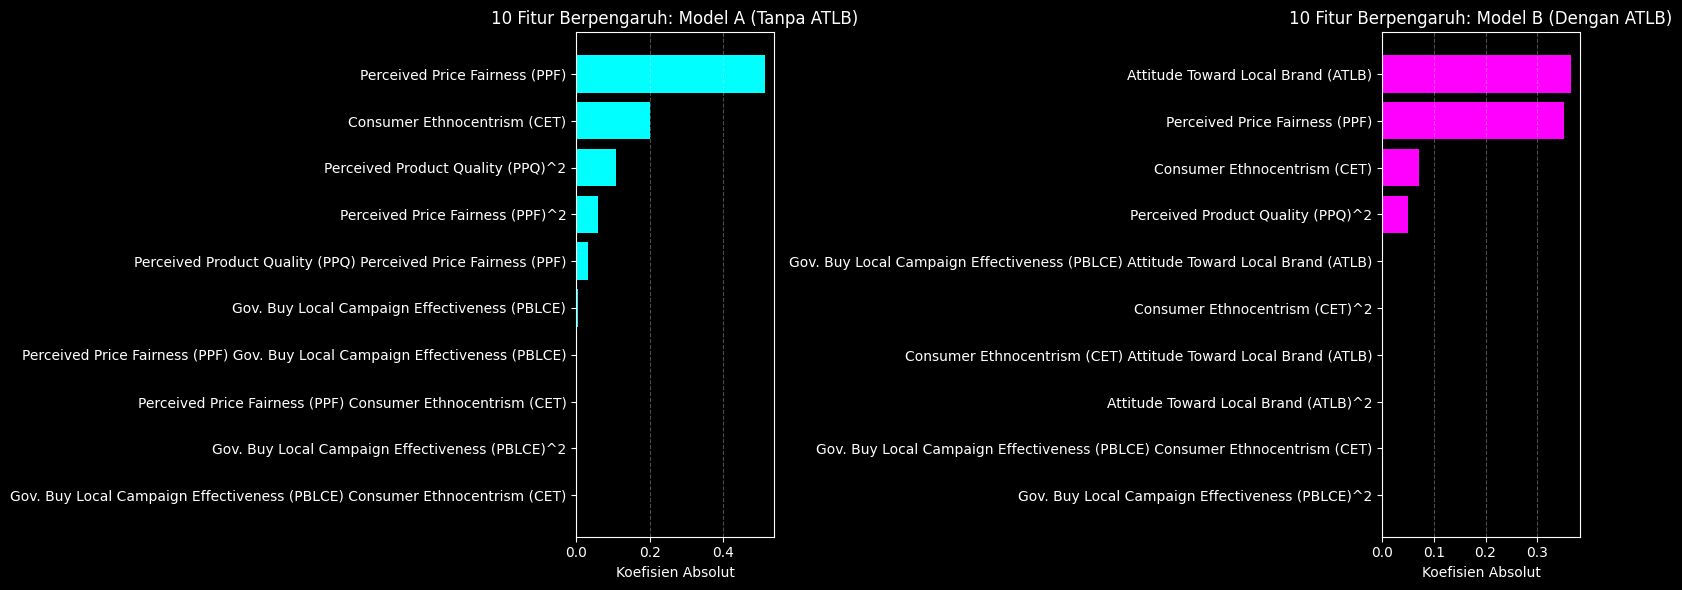

In [13]:
color_a = '#00ffff' # Neon Cyan
color_b = '#ff00ff' # Neon Magenta

en_model_a = model_en_a.named_steps['elasticnet']
en_model_b = model_en_b.named_steps['elasticnet']

importance_a = pd.DataFrame({'Feature': poly_cols_a, 'Importance': np.abs(en_model_a.coef_)})
importance_b = pd.DataFrame({'Feature': poly_cols_b, 'Importance': np.abs(en_model_b.coef_)})

top_10_a = importance_a.sort_values(by='Importance', ascending=True).tail(10)
top_10_b = importance_b.sort_values(by='Importance', ascending=True).tail(10)

# Visualisasi Feature Importance Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_10_a['Feature'], top_10_a['Importance'], color=color_a)
axes[0].set_title('10 Fitur Berpengaruh: Model A (Tanpa ATLB)', color='white')
axes[0].set_xlabel('Koefisien Absolut', color='white')
axes[0].grid(axis='x', linestyle='--', alpha=0.3)

axes[1].barh(top_10_b['Feature'], top_10_b['Importance'], color=color_b)
axes[1].set_title('10 Fitur Berpengaruh: Model B (Dengan ATLB)', color='white')
axes[1].set_xlabel('Koefisien Absolut', color='white')
axes[1].grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


--- Sampel Prediksi Elastic Net Model A (Tanpa Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407  1.335353  0.816106         0.519247
444  0.714806  0.567393         0.147413
117 -1.880795 -1.054222        -0.826573
30   0.768776  0.020758         0.748018
415 -0.415412 -1.033423         0.618011
157  1.065767  0.672407         0.393360
325  0.431731 -0.171218         0.602949
447  0.488008  0.735032        -0.247024
268 -1.880795 -1.308061        -0.572734
297  0.995550  0.481140         0.514411


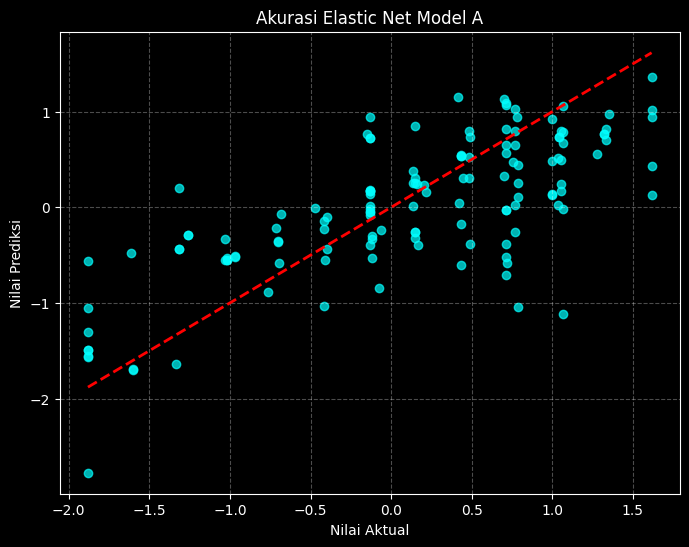

In [8]:
hasil_prediksi_en_a = pd.DataFrame({
    'Aktual': y_test_a,
    'Prediksi': y_pred_a,
    'Selisih (Error)': y_test_a - y_pred_a
})
print("\n--- Sampel Prediksi Elastic Net Model A (Tanpa Mediator ATLB) ---")
print(hasil_prediksi_en_a.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_en_a['Aktual'], hasil_prediksi_en_a['Prediksi'], alpha=0.7, color=color_a)
plt.plot([hasil_prediksi_en_a['Aktual'].min(), hasil_prediksi_en_a['Aktual'].max()],
         [hasil_prediksi_en_a['Aktual'].min(), hasil_prediksi_en_a['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual', color='white')
plt.ylabel('Nilai Prediksi', color='white')
plt.title('Akurasi Elastic Net Model A', color='white')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


--- Sampel Prediksi Elastic Net Model B (Dengan Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407  1.335353  0.933513         0.401840
444  0.714806  0.630475         0.084331
117 -1.880795 -0.548353        -1.332442
30   0.768776  0.278861         0.489915
415 -0.415412 -1.148938         0.733526
157  1.065767  0.690887         0.374880
325  0.431731 -0.129478         0.561209
447  0.488008  0.698596        -0.210588
268 -1.880795 -0.598199        -1.282596
297  0.995550  0.340991         0.654559


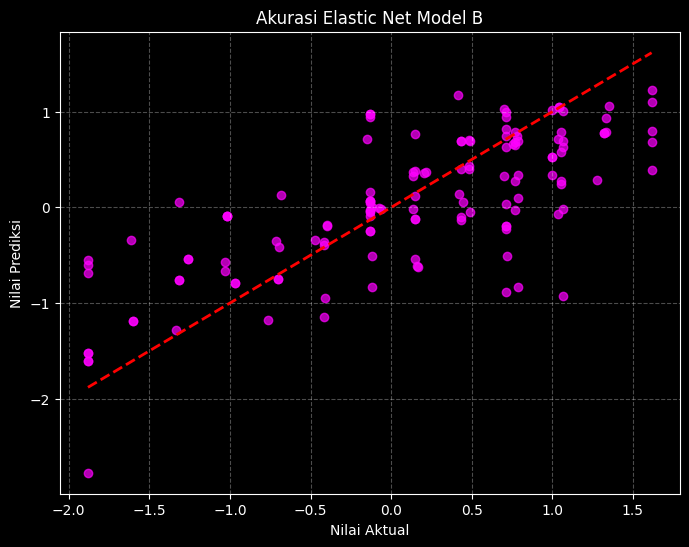

In [9]:
hasil_prediksi_en_b = pd.DataFrame({
    'Aktual': y_test_b,
    'Prediksi': y_pred_b,
    'Selisih (Error)': y_test_b - y_pred_b
})
print("\n--- Sampel Prediksi Elastic Net Model B (Dengan Mediator ATLB) ---")
print(hasil_prediksi_en_b.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_en_b['Aktual'], hasil_prediksi_en_b['Prediksi'], alpha=0.7, color=color_b)
plt.plot([hasil_prediksi_en_b['Aktual'].min(), hasil_prediksi_en_b['Aktual'].max()],
         [hasil_prediksi_en_b['Aktual'].min(), hasil_prediksi_en_b['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual', color='white')
plt.ylabel('Nilai Prediksi', color='white')
plt.title('Akurasi Elastic Net Model B', color='white')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## XGBOOST (GEN Z)

In [10]:
def process_xgboost(features, target_col, df, model_name):
    X = df[features]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # XGBoost umumnya tidak memerlukan Standard Scaler
    model = XGBRegressor(random_state=42, objective='reg:squarederror')

    # Grid Search untuk hyperparameter XGBoost
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }

    # Penambahan n_jobs=-1 agar eksekusi iterasi parameter berjalan sangat cepat
    grid = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    results = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }
    return results, best_model, X_test, y_test, y_pred

In [11]:
res_xgb_a, model_xgb_a, X_test_xgb_a, y_test_xgb_a, y_pred_xgb_a = process_xgboost(poly_cols_a, target, df_model_a, "XGBoost - Model A (Poly)")
res_xgb_b, model_xgb_b, X_test_xgb_b, y_test_xgb_b, y_pred_xgb_b = process_xgboost(poly_cols_b, target, df_model_b, "XGBoost - Model B (Poly)")

df_results_xgb = pd.DataFrame([res_xgb_a, res_xgb_b])
print("\n--- Perbandingan Performa XGBoost ---")
print(df_results_xgb)


--- Perbandingan Performa XGBoost ---
                      Model      RMSE       MAE        R2
0  XGBoost - Model A (Poly)  0.508101  0.374936  0.695113
1  XGBoost - Model B (Poly)  0.462029  0.315606  0.747897


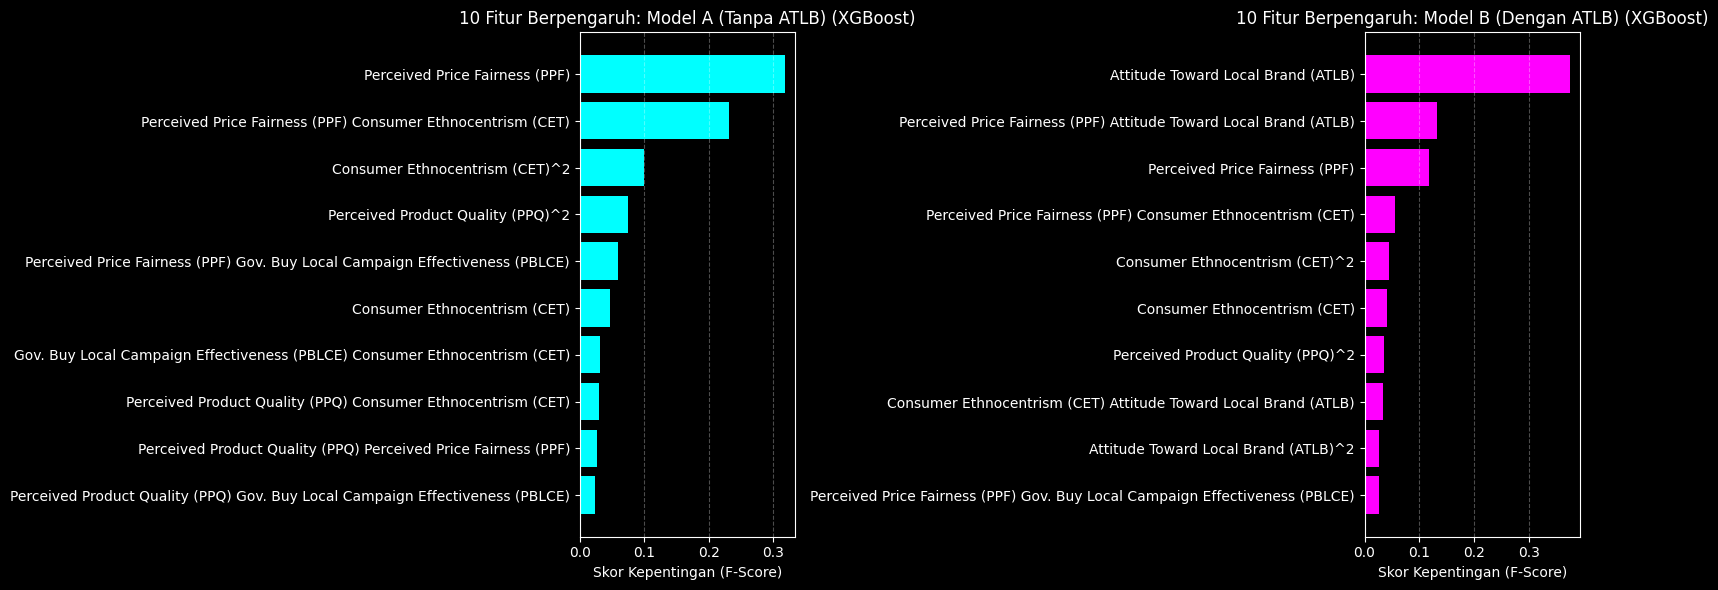

In [12]:
color_a = '#00ffff' # Neon Cyan
color_b = '#ff00ff' # Neon Magenta

# --- Visualisasi Feature Importance ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (model, feat, title, color) in enumerate([(model_xgb_a, poly_cols_a, 'Model A (Tanpa ATLB)', color_a),
                                                 (model_xgb_b, poly_cols_b, 'Model B (Dengan ATLB)', color_b)]):
    importance = pd.DataFrame({'Feature': feat, 'Importance': model.feature_importances_})

    # Membatasi ke 10 fitur terpenting
    importance = importance.sort_values('Importance', ascending=True).tail(10)

    axes[i].barh(importance['Feature'], importance['Importance'], color=color)
    axes[i].set_title(f'10 Fitur Berpengaruh: {title} (XGBoost)', color='white')
    axes[i].set_xlabel('Skor Kepentingan (F-Score)', color='white')
    axes[i].grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


--- Sampel Prediksi XGBoost Model A (Tanpa Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407  1.335353  1.219856         0.115497
444  0.714806  0.235685         0.479122
117 -1.880795 -1.067798        -0.812997
30   0.768776  0.676133         0.092643
415 -0.415412 -0.559305         0.143893
157  1.065767  0.319561         0.746206
325  0.431731  0.189842         0.241889
447  0.488008  0.460866         0.027142
268 -1.880795 -1.656202        -0.224593
297  0.995550  0.201448         0.794102


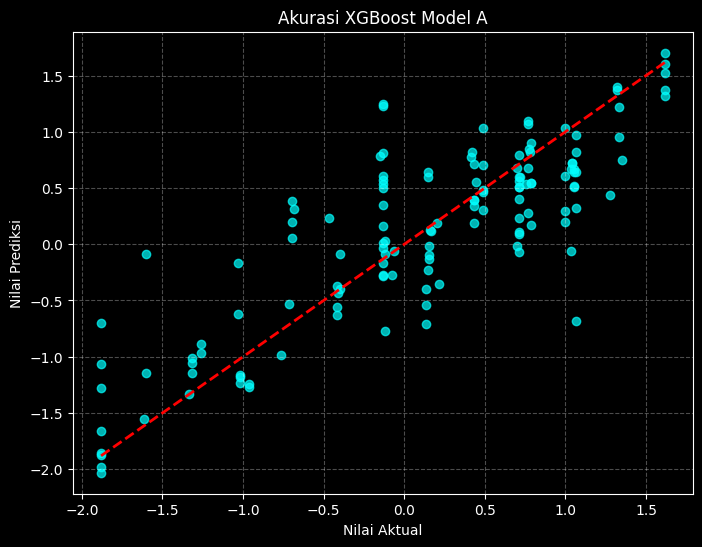

In [14]:
hasil_prediksi_xgb_a = pd.DataFrame({
    'Aktual': y_test_xgb_a,
    'Prediksi': y_pred_xgb_a,
    'Selisih (Error)': y_test_xgb_a - y_pred_xgb_a
})
print("\n--- Sampel Prediksi XGBoost Model A (Tanpa Mediator ATLB) ---")
print(hasil_prediksi_xgb_a.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_xgb_a['Aktual'], hasil_prediksi_xgb_a['Prediksi'], alpha=0.7, color=color_a)
plt.plot([hasil_prediksi_xgb_a['Aktual'].min(), hasil_prediksi_xgb_a['Aktual'].max()],
         [hasil_prediksi_xgb_a['Aktual'].min(), hasil_prediksi_xgb_a['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual', color='white')
plt.ylabel('Nilai Prediksi', color='white')
plt.title('Akurasi XGBoost Model A', color='white')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


--- Sampel Prediksi XGBoost Model B (Dengan Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407  1.335353  1.306029         0.029323
444  0.714806  0.507753         0.207053
117 -1.880795 -0.772616        -1.108179
30   0.768776  0.825953        -0.057177
415 -0.415412 -0.572548         0.157135
157  1.065767  0.761767         0.304000
325  0.431731 -0.162905         0.594636
447  0.488008  0.505756        -0.017747
268 -1.880795 -1.860936        -0.019859
297  0.995550 -0.133209         1.128759


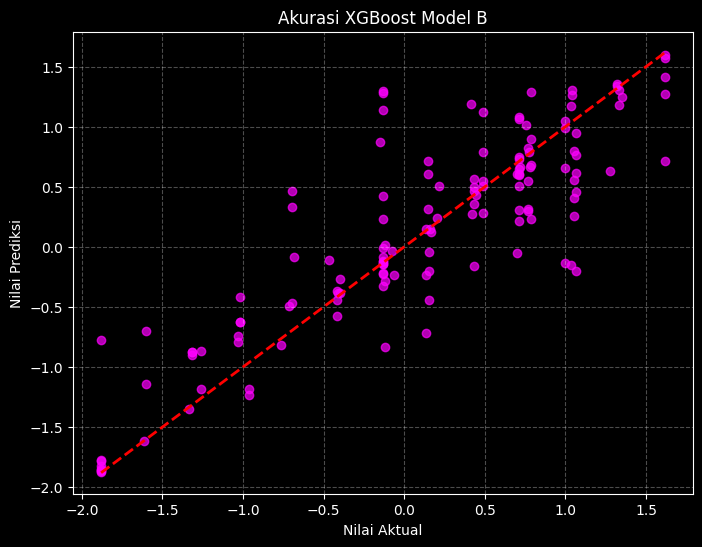

In [15]:
hasil_prediksi_xgb_b = pd.DataFrame({
    'Aktual': y_test_xgb_b,
    'Prediksi': y_pred_xgb_b,
    'Selisih (Error)': y_test_xgb_b - y_pred_xgb_b
})
print("\n--- Sampel Prediksi XGBoost Model B (Dengan Mediator ATLB) ---")
print(hasil_prediksi_xgb_b.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_xgb_b['Aktual'], hasil_prediksi_xgb_b['Prediksi'], alpha=0.7, color=color_b)
plt.plot([hasil_prediksi_xgb_b['Aktual'].min(), hasil_prediksi_xgb_b['Aktual'].max()],
         [hasil_prediksi_xgb_b['Aktual'].min(), hasil_prediksi_xgb_b['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual', color='white')
plt.ylabel('Nilai Prediksi', color='white')
plt.title('Akurasi XGBoost Model B', color='white')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## GAUSSIAN PROCESS REGRESSION (GEN Z)

In [16]:
def process_gpr_model(features, target_col, df, model_name):
    X = df[features]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # GPR sangat sensitif terhadap skala
    kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
    model = make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(kernel=kernel, random_state=42, n_restarts_optimizer=5)
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE' : mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }
    return results, model, X_test, y_test, y_pred

In [17]:
res_gpr_a, model_gpr_a, X_test_a, y_test_a, y_pred_a = process_gpr_model(poly_cols_a, target, df_model_a, "GPR Model A")
res_gpr_b, model_gpr_b, X_test_b, y_test_b, y_pred_b = process_gpr_model(poly_cols_b, target, df_model_b, "GPR Model B")

# Menampilkan Hasil Performa
df_gpr_results = pd.DataFrame([res_gpr_a, res_gpr_b])
print("\n--- Perbandingan Performa GPR ---")
print(df_gpr_results)


--- Perbandingan Performa GPR ---
         Model      RMSE       MAE        R2
0  GPR Model A  0.591122  0.479645  0.587340
1  GPR Model B  0.589027  0.445492  0.590259



Menghitung Permutation Importance untuk GPR (memanfaatkan multi-core agar cepat)...


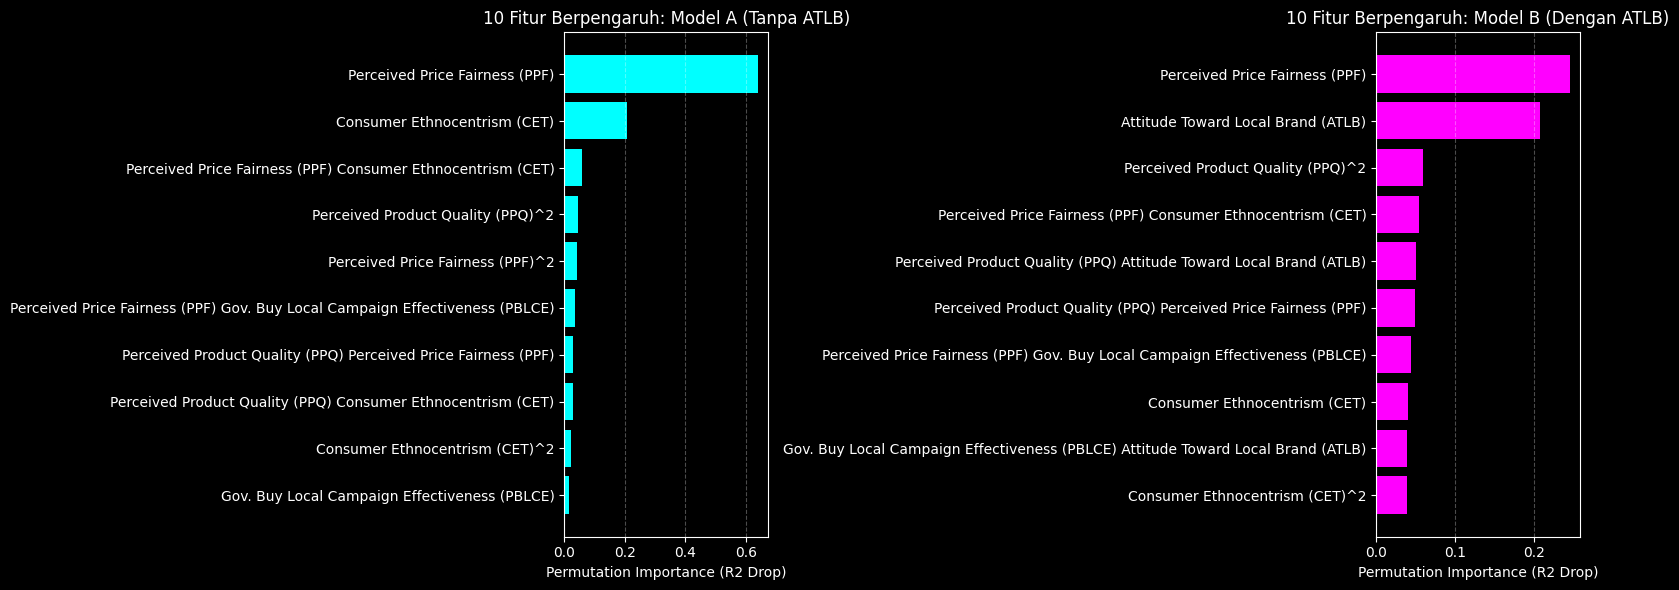

In [18]:
color_a = '#00ffff' # Neon Cyan
color_b = '#ff00ff' # Neon Magenta

print("\nMenghitung Permutation Importance untuk GPR (memanfaatkan multi-core agar cepat)...")
# Menambahkan n_jobs=-1 agar eksekusi hitungan detik
perm_a = permutation_importance(model_gpr_a, X_test_a, y_test_a, n_repeats=10, random_state=42, scoring='r2', n_jobs=-1)
importance_a = pd.DataFrame({'Feature': poly_cols_a, 'Importance': perm_a.importances_mean})

perm_b = permutation_importance(model_gpr_b, X_test_b, y_test_b, n_repeats=10, random_state=42, scoring='r2', n_jobs=-1)
importance_b = pd.DataFrame({'Feature': poly_cols_b, 'Importance': perm_b.importances_mean})

# Mengurutkan dan mengambil 10 besar saja agar grafik terbaca
top_10_a = importance_a.sort_values(by='Importance', ascending=True).tail(10)
top_10_b = importance_b.sort_values(by='Importance', ascending=True).tail(10)

# --- Visualisasi Feature Importance ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_10_a['Feature'], top_10_a['Importance'], color=color_a)
axes[0].set_title('10 Fitur Berpengaruh: Model A (Tanpa ATLB)', color='white')
axes[0].set_xlabel('Permutation Importance (R2 Drop)', color='white')
axes[0].grid(axis='x', linestyle='--', alpha=0.3)

axes[1].barh(top_10_b['Feature'], top_10_b['Importance'], color=color_b)
axes[1].set_title('10 Fitur Berpengaruh: Model B (Dengan ATLB)', color='white')
axes[1].set_xlabel('Permutation Importance (R2 Drop)', color='white')
axes[1].grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


--- Sampel Prediksi GPR Model A (Tanpa Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407  1.335353  1.145095         0.190258
444  0.714806  0.591352         0.123454
117 -1.880795 -1.348628        -0.532166
30   0.768776  0.019715         0.749061
415 -0.415412 -1.173880         0.758468
157  1.065767  0.775396         0.290371
325  0.431731 -0.113155         0.544886
447  0.488008  0.766929        -0.278921
268 -1.880795 -1.671564        -0.209231
297  0.995550  0.611449         0.384101


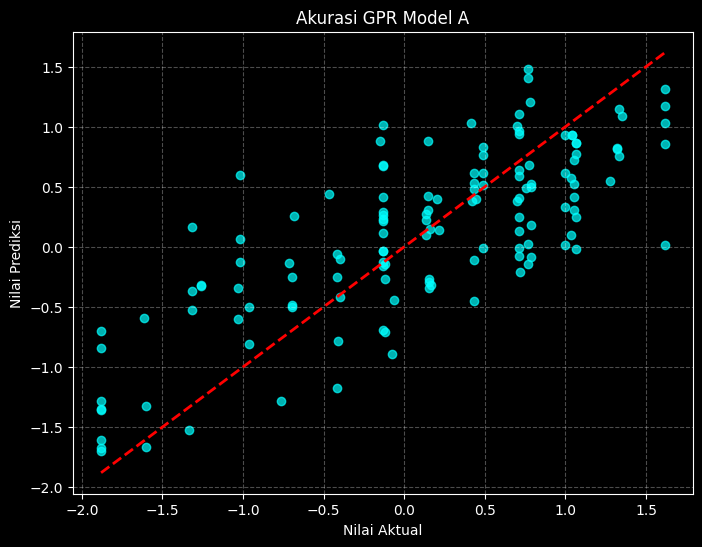

In [19]:
hasil_prediksi_gpr_a = pd.DataFrame({
    'Aktual': y_test_a,
    'Prediksi': y_pred_a,
    'Selisih (Error)': y_test_a - y_pred_a
})
print("\n--- Sampel Prediksi GPR Model A (Tanpa Mediator ATLB) ---")
print(hasil_prediksi_gpr_a.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_gpr_a['Aktual'], hasil_prediksi_gpr_a['Prediksi'], alpha=0.7, color=color_a)
plt.plot([hasil_prediksi_gpr_a['Aktual'].min(), hasil_prediksi_gpr_a['Aktual'].max()],
         [hasil_prediksi_gpr_a['Aktual'].min(), hasil_prediksi_gpr_a['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual', color='white')
plt.ylabel('Nilai Prediksi', color='white')
plt.title('Akurasi GPR Model A', color='white')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


--- 10 Sampel Prediksi GPR Model B (Dengan Mediator ATLB) ---
       Aktual  Prediksi  Selisih (Error)
407  1.335353  1.088782         0.246570
444  0.714806  0.698608         0.016198
117 -1.880795 -0.552584        -1.328211
30   0.768776  0.327163         0.441613
415 -0.415412 -0.837179         0.421767
157  1.065767  0.898993         0.166774
325  0.431731 -0.150278         0.582009
447  0.488008  0.719709        -0.231701
268 -1.880795 -2.008045         0.127250
297  0.995550  0.076010         0.919540


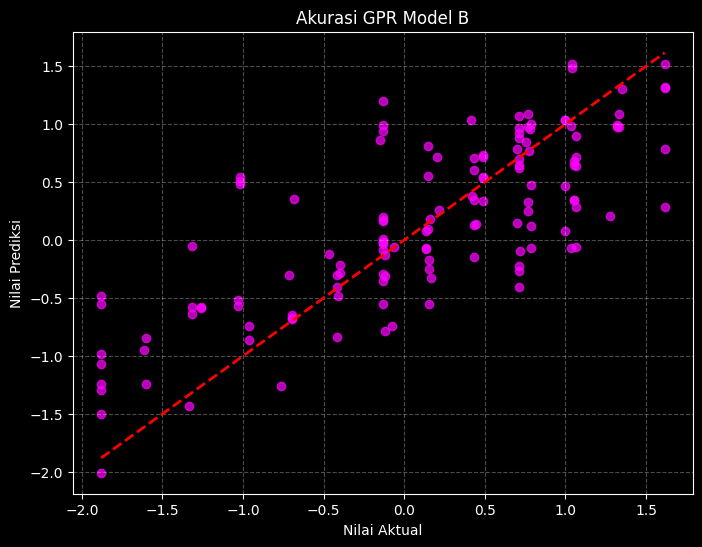

In [20]:
hasil_prediksi_gpr_b = pd.DataFrame({
    'Aktual': y_test_b,
    'Prediksi': y_pred_b,
    'Selisih (Error)': y_test_b - y_pred_b
})

print("\n--- 10 Sampel Prediksi GPR Model B (Dengan Mediator ATLB) ---")
print(hasil_prediksi_gpr_b.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(hasil_prediksi_gpr_b['Aktual'], hasil_prediksi_gpr_b['Prediksi'], alpha=0.7, color=color_b)
plt.plot([hasil_prediksi_gpr_b['Aktual'].min(), hasil_prediksi_gpr_b['Aktual'].max()],
         [hasil_prediksi_gpr_b['Aktual'].min(), hasil_prediksi_gpr_b['Aktual'].max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual', color='white')
plt.ylabel('Nilai Prediksi', color='white')
plt.title('Akurasi GPR Model B', color='white')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()